# 🌏 Optical Turbulence Climatology tại Việt Nam
## Đánh giá và Đề Xuất Vị Trí Optical Ground Station (OGS)

---

**Pipeline:**
```
ERA5 (2016–2025) → Load & Preprocess → Daocheng Parameterization
→ Cn²(h) Upper Atm + HV PBL Model → FSO Parameters (r₀, σI², θ₀)
→ Climatology Analysis → OGS Site Recommendation
```

**6 địa điểm nghiên cứu:**
| Thành phố | Vùng | Độ cao (m ASL) |
|-----------|------|----------------|
| Sa Pa | Tây Bắc | 1,570 |
| Hà Nội | Đồng bằng Bắc Bộ | 10 |
| Nha Trang | Duyên hải Nam Trung Bộ | 5 |
| Đà Lạt | Tây Nguyên | 1,500 |
| TP.HCM | Đông Nam Bộ | 10 |
| Cần Thơ | Đồng bằng sông Cửu Long | 2 |

---

> **⚠️ Giới hạn dữ liệu:** ERA5 pressure-level bắt đầu từ 500 hPa (~5.8 km).  
> PBL (0–6 km) được bổ sung bằng **Hufnagel-Valley model** với correction độ cao địa hình.

**Dữ liệu:** ERA5 daily | **Biến:** z, t, u, v | **Levels:** 500–1 hPa | **λ = 550 nm** | **ζ = 0°**

## 0. Import & Cấu Hình

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Matplotlib config ─────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 9,  'figure.dpi': 120,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

# ── City configuration ────────────────────────────────────
CITIES = {
    'Sa Pa':     {'folder': 'Sapa_2016-2025',    'prefix': 'sapa',    'elev': 1570, 'lat': 22.34, 'lon': 103.84, 'color': '#9B59B6', 'marker': 'p'},
    'Ha Noi':    {'folder': 'Hanoi_2016-2025',   'prefix': 'hn',      'elev':   10, 'lat': 21.02, 'lon': 105.85, 'color': '#E74C3C', 'marker': 'o'},
    'Nha Trang': {'folder': 'Nhatrang_2016-2025','prefix': 'nhatrang','elev':    5, 'lat': 12.24, 'lon': 109.19, 'color': '#3498DB', 'marker': '^'},
    'Da Lat':    {'folder': 'Dalat_2016-2025',   'prefix': 'dalat',   'elev': 1500, 'lat': 11.94, 'lon': 108.45, 'color': '#2ECC71', 'marker': 's'},
    'TP.HCM':    {'folder': 'TPHCM_2016-2025',   'prefix': 'hcm',     'elev':   10, 'lat': 10.82, 'lon': 106.66, 'color': '#F39C12', 'marker': 'D'},
    'Can Tho':   {'folder': 'CanTho_2016-2025',  'prefix': 'cantho',  'elev':    2, 'lat': 10.03, 'lon': 105.78, 'color': '#E67E22', 'marker': 'v'},
}
CITY_KEYS = list(CITIES.keys())

# ── Physical constants ────────────────────────────────────
g        = 9.80665        # m/s²
Rd       = 287.05         # J/(kg·K)
cp       = 1004.0         # J/(kg·K)
P0       = 1013.25        # hPa
LAMBDA_M = 0.55e-6        # m  (550 nm)
k_wave   = 2*np.pi / LAMBDA_M

# ── HV PBL model parameters ──────────────────────────────
C0_ref   = 1.7e-14        # m^{-2/3}  tropical coastal baseline
H_SCALE  = 1000.0         # m  elevation decay scale
N_PBL    = 25             # PBL altitude grid points

DATA_DIR = Path('data')
SAVE_DIR = Path('figures_v2')
SAVE_DIR.mkdir(exist_ok=True)

YEARS = list(range(2016, 2026))   # 2016–2025

print(f'Cities: {CITY_KEYS}')
print(f'Years : {YEARS[0]}–{YEARS[-1]}  ({len(YEARS)} years)')
print(f'lambda= {LAMBDA_M*1e9:.0f} nm  |  k = {k_wave:.4e} rad/m')
print('Output folder:', SAVE_DIR.resolve())

Cities: ['Sa Pa', 'Ha Noi', 'Nha Trang', 'Da Lat', 'TP.HCM', 'Can Tho']
Years : 2016–2025  (10 years)
lambda= 550 nm  |  k = 1.1424e+07 rad/m
Output folder: D:\summer research\Cn2 Vietnam\figures_v2


## 1. Load & Preprocess ERA5 Data

In [2]:
def load_city(city_key: str) -> xr.Dataset:
    """Load and concatenate all yearly NC files for a city."""
    cfg    = CITIES[city_key]
    folder = DATA_DIR / cfg['folder']
    files  = sorted(folder.glob('*.nc'))
    if not files:
        raise FileNotFoundError(f'No .nc files in {folder}')
    ds_list = [xr.open_dataset(f) for f in files]
    ds = xr.concat(ds_list, dim='valid_time')
    ds = ds.rename({'valid_time': 'time', 'pressure_level': 'level'})
    ds = ds.sortby('time')
    # Spatial mean over the lat/lon grid
    ds = ds.mean(dim=['latitude', 'longitude'])
    return ds


city_ds = {}
print(f'{'City':<12} | {'Files':>5} | {'Days':>5} | H_bottom(km) | T_range(K)')
print('-' * 60)
for city in CITY_KEYS:
    try:
        ds = load_city(city)
        city_ds[city] = ds
        n_days = len(ds.time)
        H_bot  = float(ds['z'].isel(level=0).mean()) / g / 1000
        T_min  = float(ds['t'].min())
        T_max  = float(ds['t'].max())
        n_files= len(list((DATA_DIR / CITIES[city]['folder']).glob('*.nc')))
        print(f'{city:<12} | {n_files:>5} | {n_days:>5} | '
              f'{H_bot:>12.2f} | {T_min:.1f}–{T_max:.1f}')
    except Exception as e:
        print(f'{city:<12} ERROR: {e}')

print('\nAll datasets loaded.')

City         | Files |  Days | H_bottom(km) | T_range(K)
------------------------------------------------------------


Sa Pa        |    10 |  2370 |         5.85 | 188.4–275.1


Ha Noi       |    10 |  2370 |         5.86 | 187.8–273.9


Nha Trang    |    10 |  2370 |         5.87 | 184.7–273.5


Da Lat       |    10 |  2370 |         5.87 | 184.7–273.4


TP.HCM       |    10 |  2370 |         5.87 | 185.1–273.6


Can Tho      |    10 |  2370 |         5.87 | 185.1–274.2

All datasets loaded.


## 2. Daocheng / Tatarskii Parameterization → Cn²(h) Upper Atmosphere

Từ ERA5 pressure levels (~5.8–48 km):

$$M = -\frac{79\times10^{-6}\,P}{T^2}\left(\frac{dT}{dh}+\Gamma_d\right), 
\quad L_0 = 0.1\,h^{1/2}\,e^{-h/8000},
\quad C_n^2 = 2.8\,M^2\,L_0^{4/3}$$

In [3]:
def daocheng_cn2(ds: xr.Dataset):
    """
    Tatarskii-Daocheng Cn² from ERA5 pressure-level data.
    Returns:
      cn2  : (n_time, n_layer)  m^{-2/3}
      h    : (n_time, n_layer)  m  (mid-layer heights)
      times: pd.DatetimeIndex
    """
    T  = ds['t'].values          # (n_time, n_lev)
    P  = ds['level'].values      # (n_lev,)  hPa
    Z  = ds['z'].values          # geopotential m²/s²
    U  = ds['u'].values
    V  = ds['v'].values
    H  = Z / g                   # geopotential height  [m]

    Gamma_d = g / cp             # dry adiabatic lapse rate  K/m
    Rd_cp   = Rd / cp
    A2      = 2.8                # Tatarskii constant

    n_t, n_l = T.shape
    cn2_out  = np.zeros((n_t, n_l - 1))
    h_out    = np.zeros((n_t, n_l - 1))

    for k in range(n_l - 1):
        dH    = H[:, k+1] - H[:, k]
        dH_s  = np.where(np.abs(dH) < 1.0, np.sign(dH + 1e-10), dH)
        T_mid = 0.5 * (T[:, k] + T[:, k+1])
        H_mid = 0.5 * (H[:, k] + H[:, k+1])
        P_mid = 0.5 * (P[k] + P[k+1])

        dT_dh = (T[:, k+1] - T[:, k]) / dH_s
        M     = -79e-6 * P_mid / (T_mid**2) * (dT_dh + Gamma_d)

        H_abs = np.where(H_mid < 1.0, 1.0, np.abs(H_mid))
        L0    = np.clip(0.1 * H_abs**0.5 * np.exp(-H_abs / 8000.0), 0.1, 80.0)

        val   = np.clip(np.abs(A2 * M**2 * L0**(4./3.)), 1e-20, 1e-10)
        cn2_out[:, k] = val
        h_out[:, k]   = np.abs(H_mid)

    times = pd.to_datetime(ds['time'].values)
    return cn2_out, h_out, times


era5_cn2 = {}
print(f'{'City':<12} | {'log10(Cn2_mean)':>16} | {'H_range (km)':>14}')
print('-' * 50)
for city in CITY_KEYS:
    c2, hm, tm = daocheng_cn2(city_ds[city])
    era5_cn2[city] = {'cn2': c2, 'h': hm, 'time': tm}
    print(f'{city:<12} | {np.log10(np.nanmean(c2)):>16.3f} | '
          f'{hm.min()/1000:.1f}–{hm.max()/1000:.1f}')

City         |  log10(Cn2_mean) |   H_range (km)
--------------------------------------------------
Sa Pa        |          -16.900 | 6.5–42.2
Ha Noi       |          -16.909 | 6.6–42.2
Nha Trang    |          -16.928 | 6.7–42.1
Da Lat       |          -16.927 | 6.7–42.1
TP.HCM       |          -16.927 | 6.7–42.1
Can Tho      |          -16.928 | 6.7–42.1


## 3. Hufnagel-Valley PBL Model (0 m → ~5.8 km)

Bổ sung lớp khí quyển thấp không có trong ERA5 pressure-level data:

$$C_n^2(h) = 0.00594\left(\frac{v_w}{27}\right)^2(10^{-5}h)^{10}e^{-h/1000}
+2.7\times10^{-16}e^{-h/1500}
+C_0\,e^{-h/100}$$

**Elevation correction** (lý do Đà Lạt & Sa Pa tốt hơn):
$$C_0 = C_{0,\text{ref}}\cdot\exp(-h_{\text{elev}}/H_{\text{scale}})$$

In [4]:
def hv_profile(h_m: np.ndarray, vw: float, C0: float) -> np.ndarray:
    """Modified Hufnagel-Valley Cn²(h) profile."""
    h = np.where(h_m < 1.0, 1.0, h_m.astype(float))
    t1 = 0.00594 * (vw/27.0)**2 * (1e-5*h)**10 * np.exp(-h/1000.0)
    t2 = 2.7e-16 * np.exp(-h/1500.0)
    t3 = C0 * np.exp(-h/100.0)
    return np.clip(t1 + t2 + t3, 1e-20, 1e-10)


pbl_cn2 = {}
print(f'{'City':<12} | {'Elev(m)':>7} | {'C0':>10} | {'log10(PBL mean)':>16} | {'PBL h (km)'}')
print('-' * 68)

for city in CITY_KEYS:
    cfg   = CITIES[city]
    elev  = cfg['elev']
    times = era5_cn2[city]['time']
    ds    = city_ds[city]

    # Wind speed at lowest pressure level (500 hPa) as HV wind parameter
    U500  = ds['u'].isel(level=0).values   # (n_time,)
    V500  = ds['v'].isel(level=0).values
    vw    = np.sqrt(U500**2 + V500**2)

    # Surface Cn² reduced by terrain elevation
    C0    = C0_ref * np.exp(-elev / H_SCALE)

    # Altitude grid: terrain → ERA5 bottom (~5800 m)
    h_top = 5800.0
    h_grid = np.linspace(float(elev) + 20.0, h_top, N_PBL)

    n_t   = len(times)
    cn2_p = np.zeros((n_t, N_PBL))
    h_p   = np.zeros((n_t, N_PBL))

    for i in range(n_t):
        cn2_p[i, :] = hv_profile(h_grid, vw[i], C0)
        h_p[i, :]   = h_grid

    pbl_cn2[city] = {'cn2': cn2_p, 'h': h_p, 'C0': C0, 'elev': elev}
    print(f'{city:<12} | {elev:>7} | {C0:>10.2e} | '
          f'{np.log10(np.nanmean(cn2_p)):>16.3f} | '
          f'{h_grid[0]/1000:.2f}–{h_grid[-1]/1000:.2f}')

City         | Elev(m) |         C0 |  log10(PBL mean) | PBL h (km)
--------------------------------------------------------------------


Sa Pa        |    1570 |   3.54e-15 |          -16.486 | 1.59–5.80


Ha Noi       |      10 |   1.68e-14 |          -15.208 | 0.03–5.80


Nha Trang    |       5 |   1.69e-14 |          -15.187 | 0.03–5.80


Da Lat       |    1500 |   3.79e-15 |          -16.478 | 1.52–5.80
TP.HCM       |      10 |   1.68e-14 |          -15.209 | 0.03–5.80


Can Tho      |       2 |   1.70e-14 |          -15.175 | 0.02–5.80


## 4. Full Column: PBL + ERA5 → Tính FSO Parameters

In [5]:
def compute_fso(cn2_arr, h_arr, h_surface=0.0, lam=0.55e-6):
    """
    Compute r0, sigma2_I, theta0 from full-column Cn²(h) profile.
    Integration starts at h_surface (terrain elevation of each city).
    """
    kw    = 2 * np.pi / lam
    r0_l  = []; si_l = []; th_l = []

    for i in range(cn2_arr.shape[0]):
        cn2 = cn2_arr[i]; h = h_arr[i]
        # Keep only layers above terrain
        mask = h >= h_surface
        if mask.sum() < 2:
            r0_l.append(np.nan); si_l.append(np.nan); th_l.append(np.nan)
            continue
        cn2 = cn2[mask]; h = h[mask]
        idx = np.argsort(h)
        h_s = h[idx]; c_s = cn2[idx]

        dh     = np.diff(h_s)
        c_mid  = 0.5 * (c_s[:-1] + c_s[1:])
        h_mid  = 0.5 * (h_s[:-1] + h_s[1:])
        h_pos  = np.where(h_mid < 0, 0.0, h_mid)

        I0    = max(np.sum(c_mid * dh), 1e-25)
        r0    = (0.423 * kw**2 * I0)**(-3./5.)

        I_si  = np.sum(c_mid * h_pos**(5./6.) * dh)
        si    = 2.25 * kw**(7./6.) * I_si

        I_h53 = np.sum(c_mid * h_pos**(5./3.) * dh)
        hbar  = (I_h53 / I0)**(3./5.) if (I0 > 0 and I_h53 > 0) else 1e5
        th    = np.degrees(0.314 * r0 / hbar) * 3600.0

        r0_l.append(r0 * 100.0)   # → cm
        si_l.append(si)
        th_l.append(th)

    return np.array(r0_l), np.array(si_l), np.array(th_l)


# ── Build full-column dataset and compute FSO ─────────────
fso  = {}
full = {}

print(f'{'City':<12} | {'r0_mean(cm)':>12} | {'sigma2_mean':>12} | {'theta0(as)':>12}')
print('-' * 56)

for city in CITY_KEYS:
    cn2_f = np.concatenate([pbl_cn2[city]['cn2'], era5_cn2[city]['cn2']], axis=1)
    h_f   = np.concatenate([pbl_cn2[city]['h'],   era5_cn2[city]['h']],   axis=1)
    times = era5_cn2[city]['time']
    full[city] = {'cn2': cn2_f, 'h': h_f, 'time': times}

    r0, si, th = compute_fso(cn2_f, h_f, h_surface=float(CITIES[city]['elev']))

    df = pd.DataFrame({'time': times, 'r0_cm': r0,
                       'sigma2_I': si, 'theta0_as': th})
    df['month']  = pd.to_datetime(df['time']).dt.month
    df['year']   = pd.to_datetime(df['time']).dt.year
    df['season'] = df['month'].map({
        12:'Dong', 1:'Dong',  2:'Dong',
        3:'Xuan',  4:'Xuan',  5:'Xuan',
        6:'He',    7:'He',    8:'He',
        9:'Thu',   10:'Thu',  11:'Thu',
    })
    fso[city] = df.set_index('time')
    print(f'{city:<12} | {r0.mean():>12.4f} | {si.mean():>12.6f} | {th.mean():>12.4f}')

print('\nFSO parameters computed for all cities.')

City         |  r0_mean(cm) |  sigma2_mean |   theta0(as)
--------------------------------------------------------


Sa Pa        |      16.1891 |     0.270105 |       1.0545


Ha Noi       |       5.2916 |     0.338807 |       1.0497


Nha Trang    |       5.1760 |     0.331140 |       1.0628


Da Lat       |      16.4140 |     0.258140 |       1.0724


TP.HCM       |       5.3081 |     0.329656 |       1.0625


Can Tho      |       5.0977 |     0.331667 |       1.0643

FSO parameters computed for all cities.


## 5. Climatology Theo Tháng

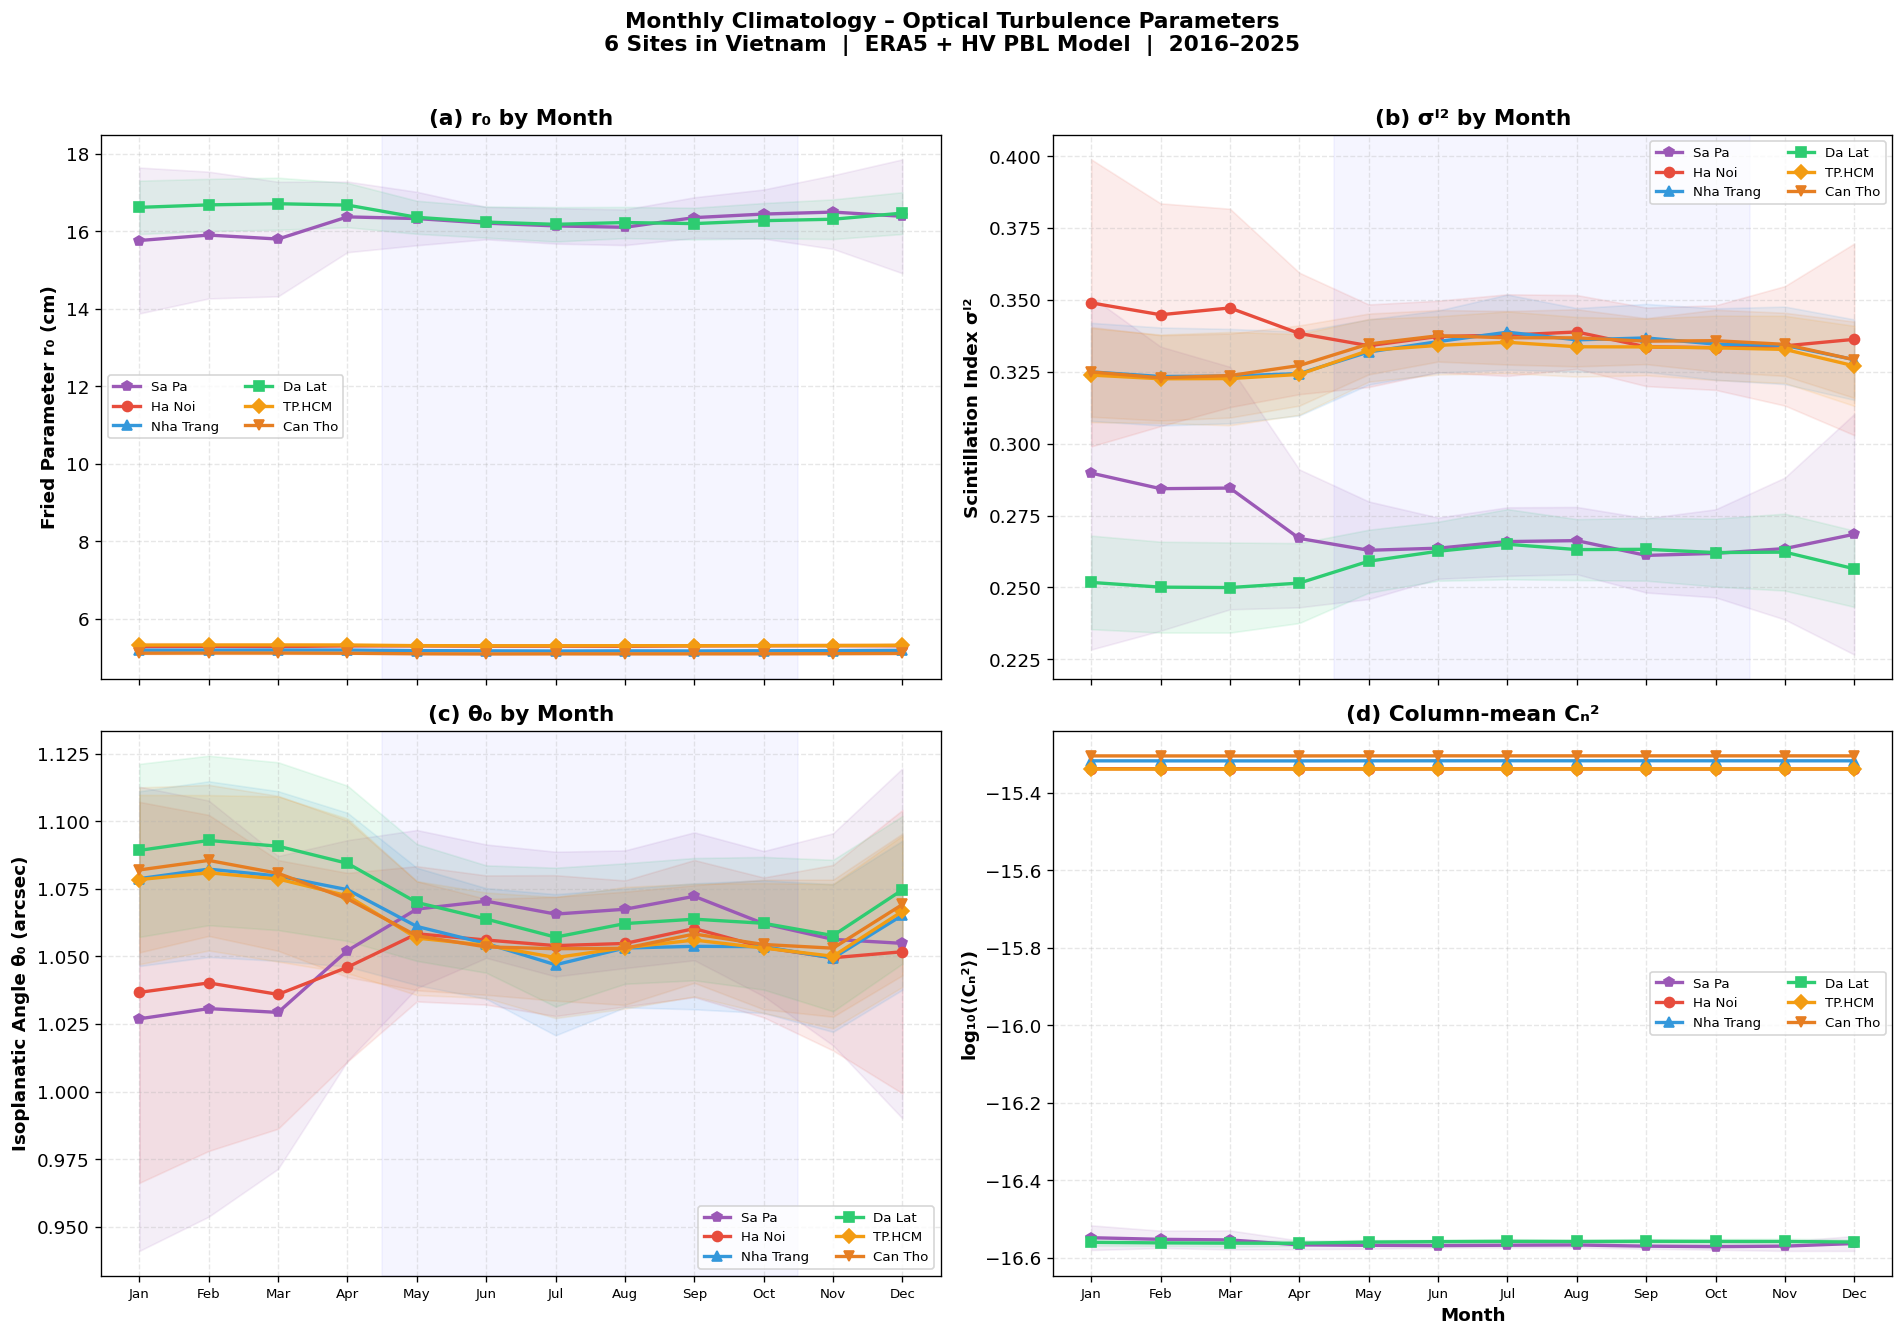

Saved fig01


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
fig.suptitle(
    'Monthly Climatology – Optical Turbulence Parameters\n'
    '6 Sites in Vietnam  |  ERA5 + HV PBL Model  |  2016–2025',
    fontsize=13, fontweight='bold', y=1.01
)

mlabs = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months = range(1, 13)

panels = [
    (axes[0,0], 'r0_cm',    'Fried Parameter r\u2080 (cm)',     '(a) r\u2080 by Month'),
    (axes[0,1], 'sigma2_I', 'Scintillation Index \u03c3\u1d35\u00b2', '(b) \u03c3\u1d35\u00b2 by Month'),
    (axes[1,0], 'theta0_as','Isoplanatic Angle \u03b8\u2080 (arcsec)', '(c) \u03b8\u2080 by Month'),
]

for ax, col, ylabel, title in panels:
    for city in CITY_KEYS:
        cfg = CITIES[city]
        m   = fso[city][col].groupby(fso[city]['month']).mean()
        s   = fso[city][col].groupby(fso[city]['month']).std()
        ax.plot(m.index, m.values, 'o-', color=cfg['color'],
                marker=cfg['marker'], label=city, lw=2, ms=6)
        ax.fill_between(m.index, m-s, m+s, alpha=0.10, color=cfg['color'])
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='best', fontsize=8, ncol=2)
    ax.set_xticks(list(months)); ax.set_xticklabels(mlabs, fontsize=8)
    # Highlight rainy season (May-Oct)
    ax.axvspan(4.5, 10.5, alpha=0.04, color='blue', label='_Wet')

# Panel (d): column-mean log Cn²
ax = axes[1, 1]
for city in CITY_KEYS:
    cfg = CITIES[city]
    c2  = np.nanmean(full[city]['cn2'], axis=1)
    tm  = full[city]['time']
    lcn2 = pd.Series(np.log10(np.clip(c2, 1e-20, None)), index=tm)
    m = lcn2.groupby(tm.month).mean()
    s = lcn2.groupby(tm.month).std()
    ax.plot(m.index, m.values, 'o-', color=cfg['color'],
            marker=cfg['marker'], label=city, lw=2, ms=6)
    ax.fill_between(m.index, m-s, m+s, alpha=0.10, color=cfg['color'])
ax.set_ylabel('log\u2081\u2080(\u27e8C\u2099\u00b2\u27e9)', fontweight='bold')
ax.set_xlabel('Month', fontweight='bold')
ax.set_title('(d) Column-mean C\u2099\u00b2', fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.set_xticks(list(months)); ax.set_xticklabels(mlabs, fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig01_monthly_climatology.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig01')

## 6. Phân Tích Theo Mùa

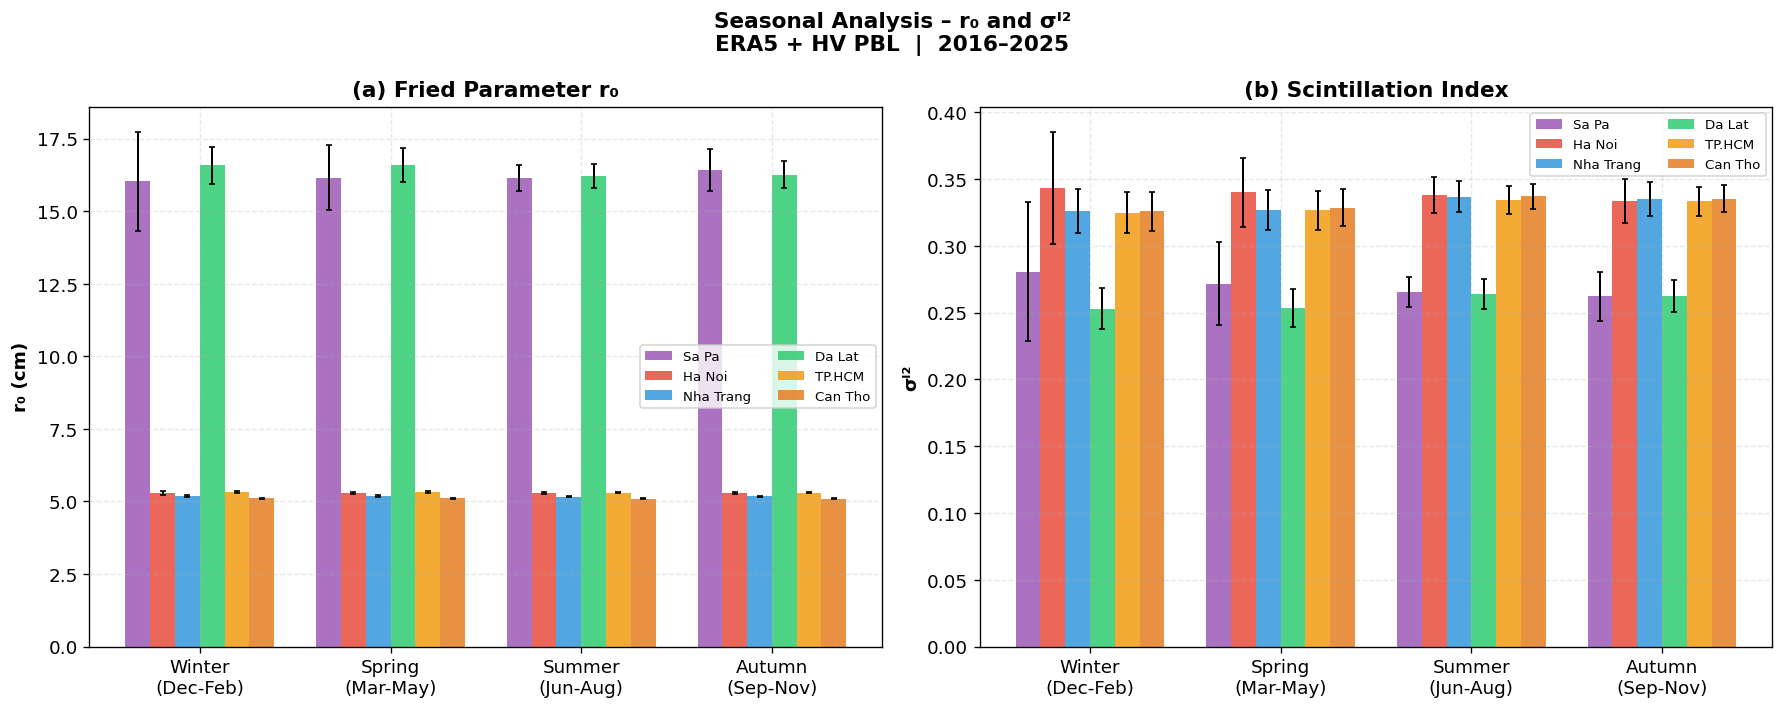

Saved fig02


In [7]:
SEASON_ORDER  = ['Dong', 'Xuan', 'He', 'Thu']
SEASON_LABELS = ['Winter\n(Dec-Feb)', 'Spring\n(Mar-May)',
                 'Summer\n(Jun-Aug)', 'Autumn\n(Sep-Nov)']
SEASON_COLORS = ['#5B9BD5', '#70AD47', '#FF6B6B', '#FFC000']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Seasonal Analysis – r\u2080 and \u03c3\u1d35\u00b2\n'
             'ERA5 + HV PBL  |  2016–2025', fontsize=13, fontweight='bold')

x = np.arange(len(SEASON_ORDER)); w = 0.13

for ax, (col, ylabel, title) in zip(axes, [
    ('r0_cm',   'r\u2080 (cm)',           '(a) Fried Parameter r\u2080'),
    ('sigma2_I','\u03c3\u1d35\u00b2',     '(b) Scintillation Index'),
]):
    for i, city in enumerate(CITY_KEYS):
        cfg  = CITIES[city]
        means= [fso[city].loc[fso[city]['season']==s, col].mean() for s in SEASON_ORDER]
        stds = [fso[city].loc[fso[city]['season']==s, col].std()  for s in SEASON_ORDER]
        ax.bar(x + i*w, means, w, yerr=stds, label=city,
               color=cfg['color'], alpha=0.85,
               error_kw=dict(elinewidth=1.2, capsize=2))
    ax.set_xticks(x + w*2.5); ax.set_xticklabels(SEASON_LABELS)
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig02_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig02')

## 7. Chuỗi Thời Gian 2016–2025

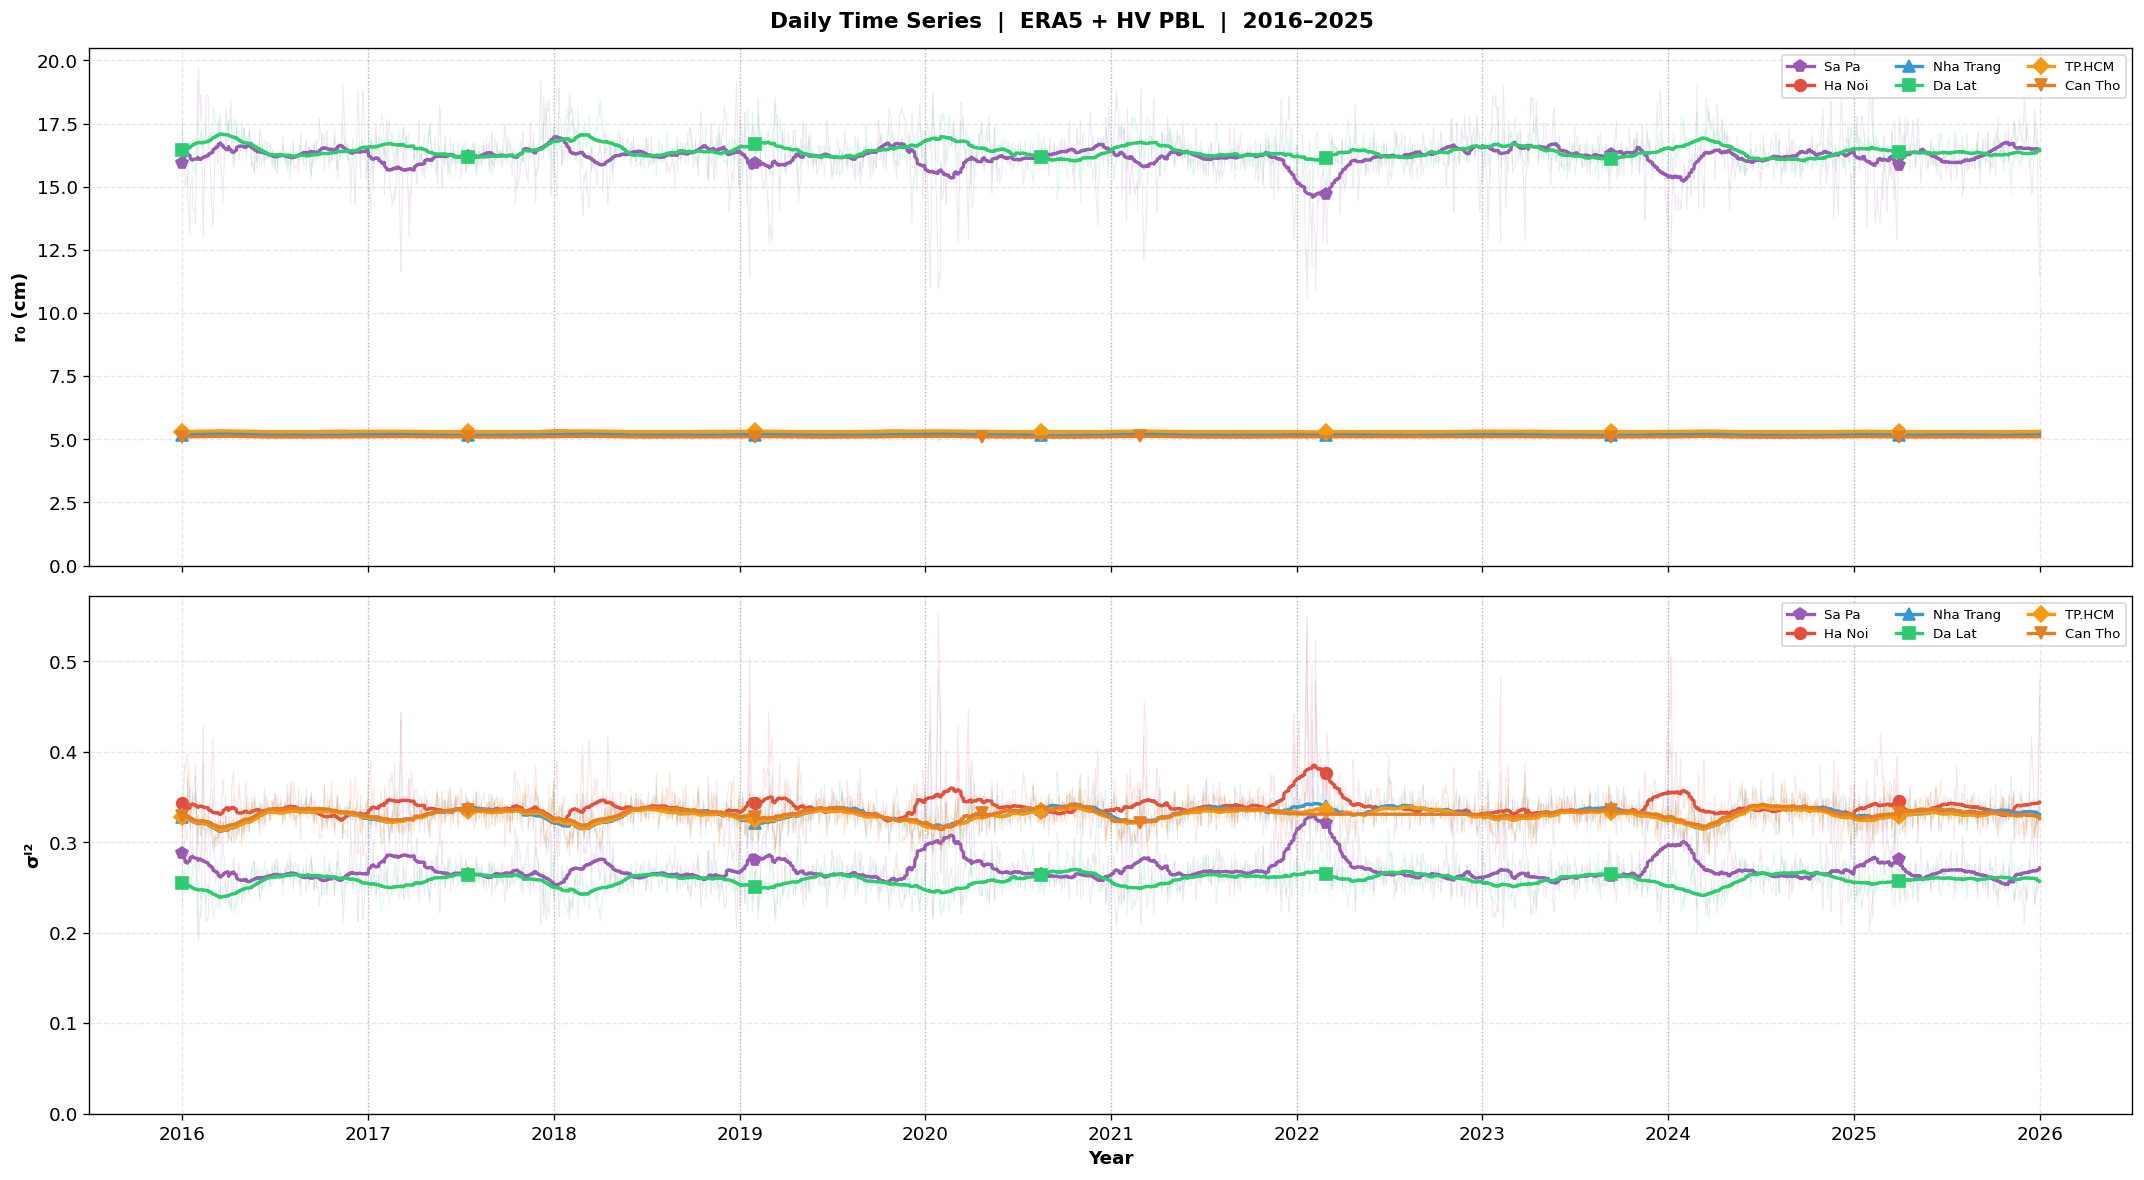

Saved fig03


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle('Daily Time Series  |  ERA5 + HV PBL  |  2016–2025',
             fontsize=13, fontweight='bold')

for ax, (col, ylabel) in zip(axes, [
    ('r0_cm',   'r\u2080 (cm)'),
    ('sigma2_I','\u03c3\u1d35\u00b2'),
]):
    for city in CITY_KEYS:
        cfg = CITIES[city]
        df  = fso[city]
        sm  = df[col].rolling(60, center=True, min_periods=15).mean()
        ax.plot(df.index, df[col], alpha=0.15, color=cfg['color'], lw=0.6)
        ax.plot(df.index, sm, color=cfg['color'], lw=2,
                marker=cfg['marker'], markevery=365, ms=7, label=city)
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=3)
    ax.set_ylim(bottom=0)
    # Year grid lines
    for yr in range(2017, 2026):
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray', ls=':', alpha=0.4, lw=0.8)

axes[1].set_xlabel('Year', fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig03_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig03')

## 8. Vertical Profile Cn²(h) – Full Column

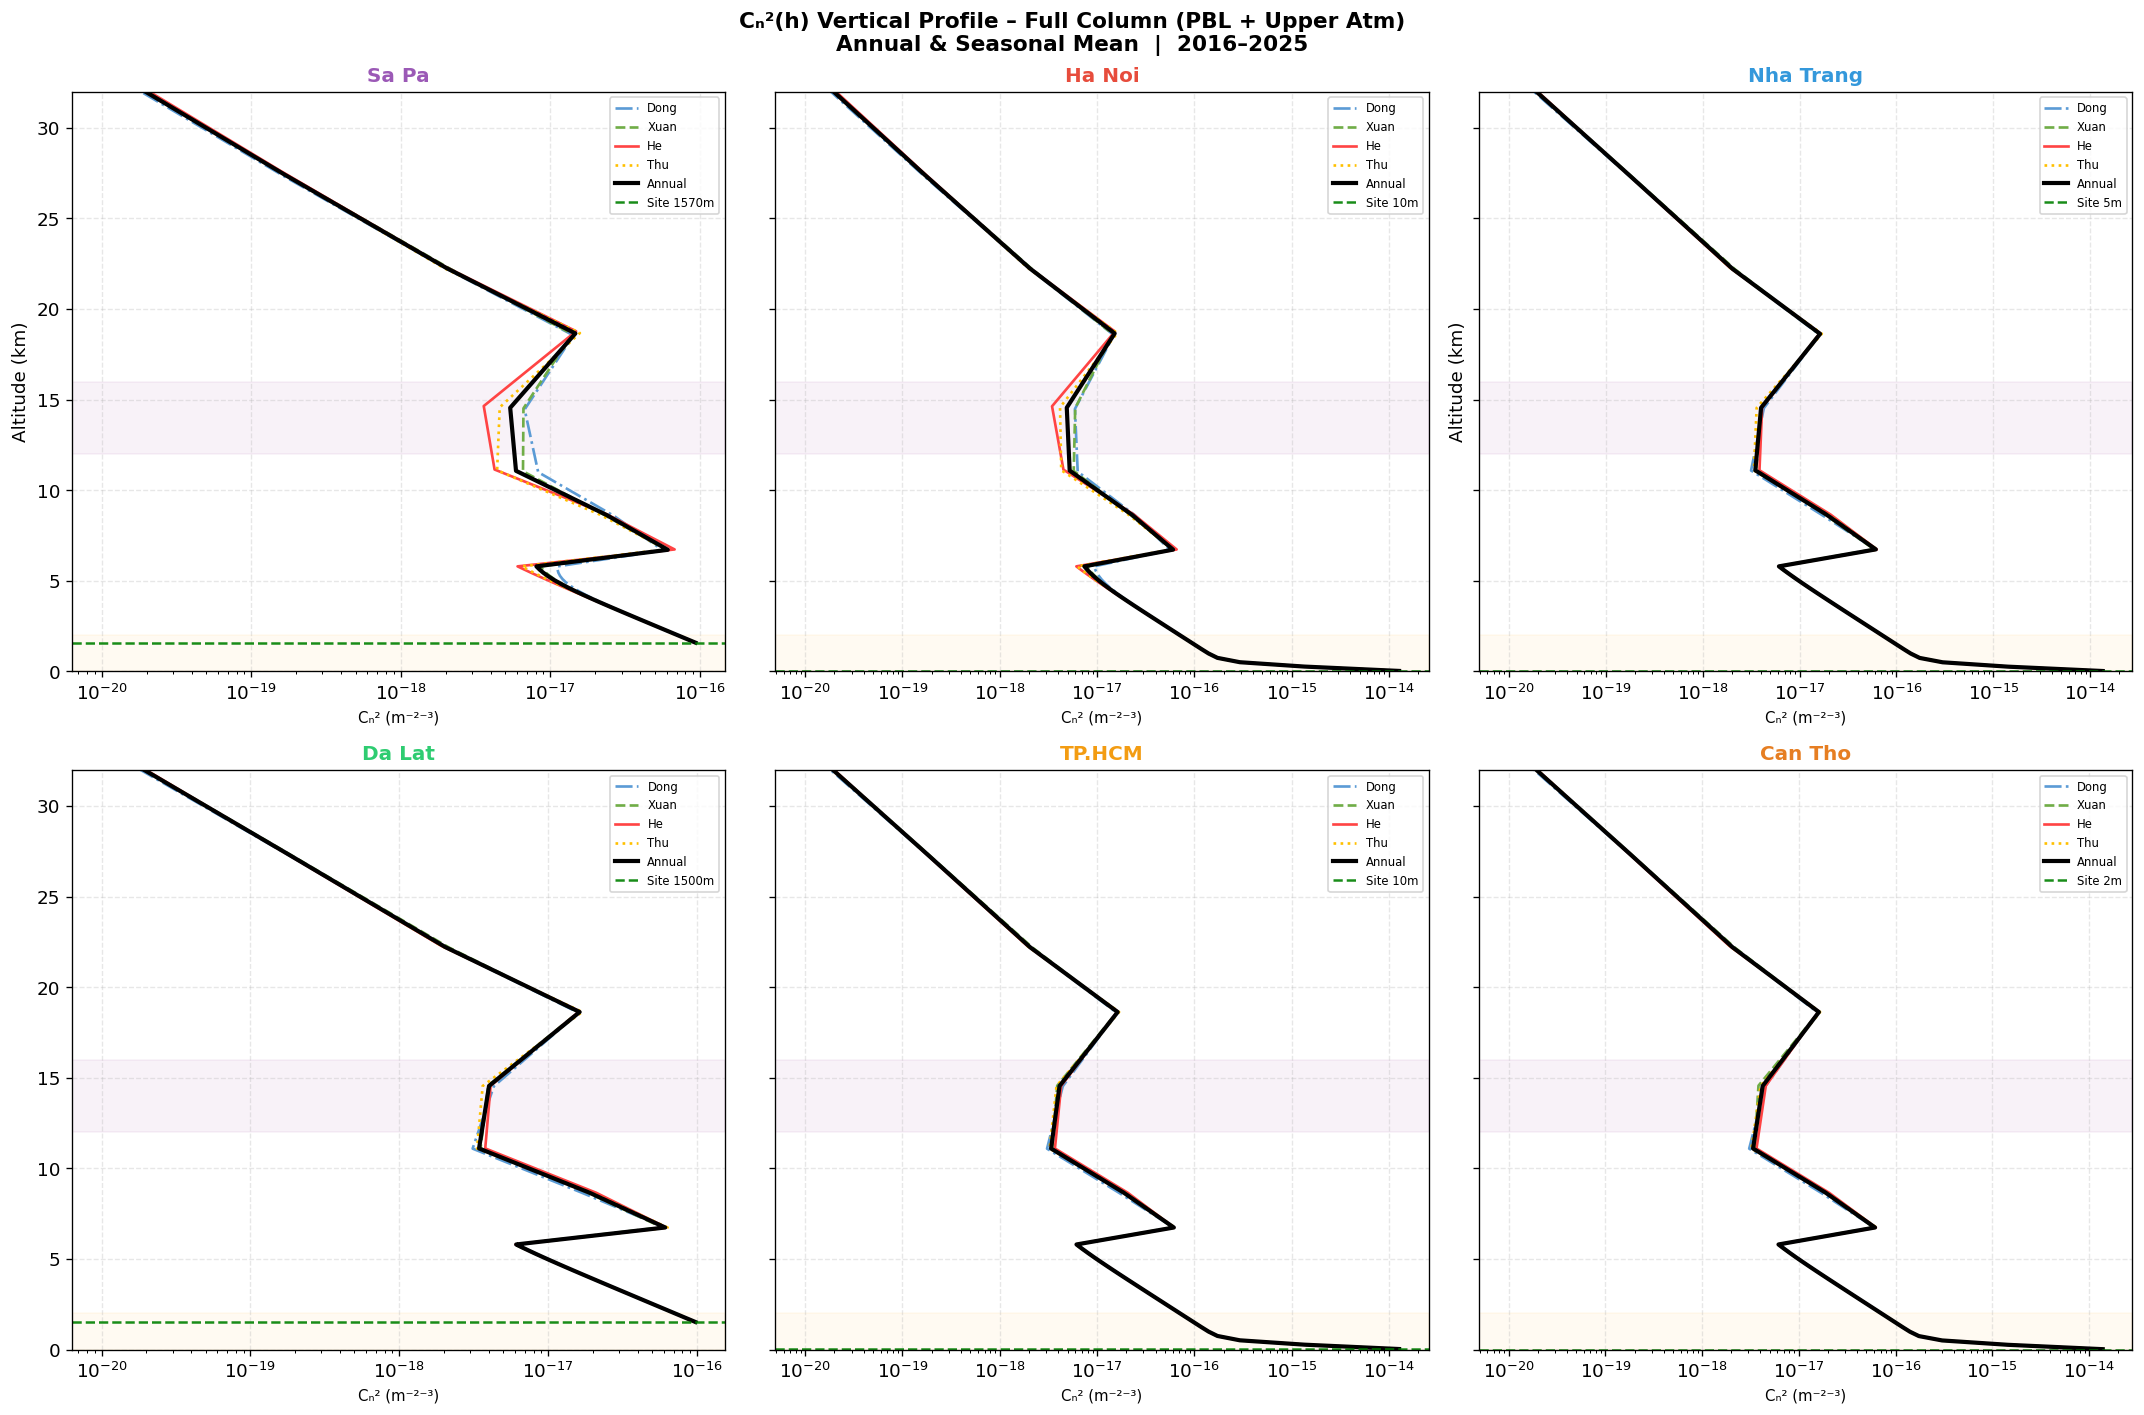

Saved fig04


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey=True)
fig.suptitle('C\u2099\u00b2(h) Vertical Profile – Full Column (PBL + Upper Atm)\n'
             'Annual & Seasonal Mean  |  2016–2025',
             fontsize=13, fontweight='bold')

s_colors = {'Dong':'#5B9BD5','Xuan':'#70AD47','He':'#FF4444','Thu':'#FFC000','Annual':'black'}
s_ls     = {'Dong':'-.','Xuan':'--','He':'-','Thu':':','Annual':'-'}
s_lw     = {'Dong':1.6,'Xuan':1.6,'He':1.6,'Thu':1.6,'Annual':2.5}

for ax, city in zip(axes.flatten(), CITY_KEYS):
    cfg     = CITIES[city]
    cn2_all = full[city]['cn2']
    h_all   = full[city]['h']
    tm      = full[city]['time']
    seas    = fso[city]['season'].reindex(tm).values

    for sname in ['Dong','Xuan','He','Thu','Annual']:
        if sname == 'Annual':
            c2 = np.nanmean(cn2_all, axis=0)
            hm = np.nanmean(h_all,   axis=0)
        else:
            mask = seas == sname
            if mask.sum() == 0: continue
            c2 = np.nanmean(cn2_all[mask], axis=0)
            hm = np.nanmean(h_all[mask],   axis=0)
        idx = np.argsort(hm)
        ax.semilogx(c2[idx], hm[idx]/1000,
                    color=s_colors[sname], ls=s_ls[sname],
                    lw=s_lw[sname], label=sname)

    ax.axhline(cfg['elev']/1000, color='green', ls='--', lw=1.5, alpha=0.9,
               label=f'Site {cfg["elev"]}m')
    ax.axhspan(0, 2, alpha=0.05, color='orange')    # PBL
    ax.axhspan(12, 16, alpha=0.05, color='purple')  # Tropopause
    ax.set_xlabel('C\u2099\u00b2 (m\u207b\u00b2\u207b\u00b3)', fontsize=9)
    ax.set_ylabel('Altitude (km)' if city in ['Sa Pa','Nha Trang'] else '')
    ax.set_title(city, fontweight='bold', color=cfg['color'], fontsize=12)
    ax.set_ylim(0, 32)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig04_vertical_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig04')

## 9. Heatmap: Cn²(h) × Tháng

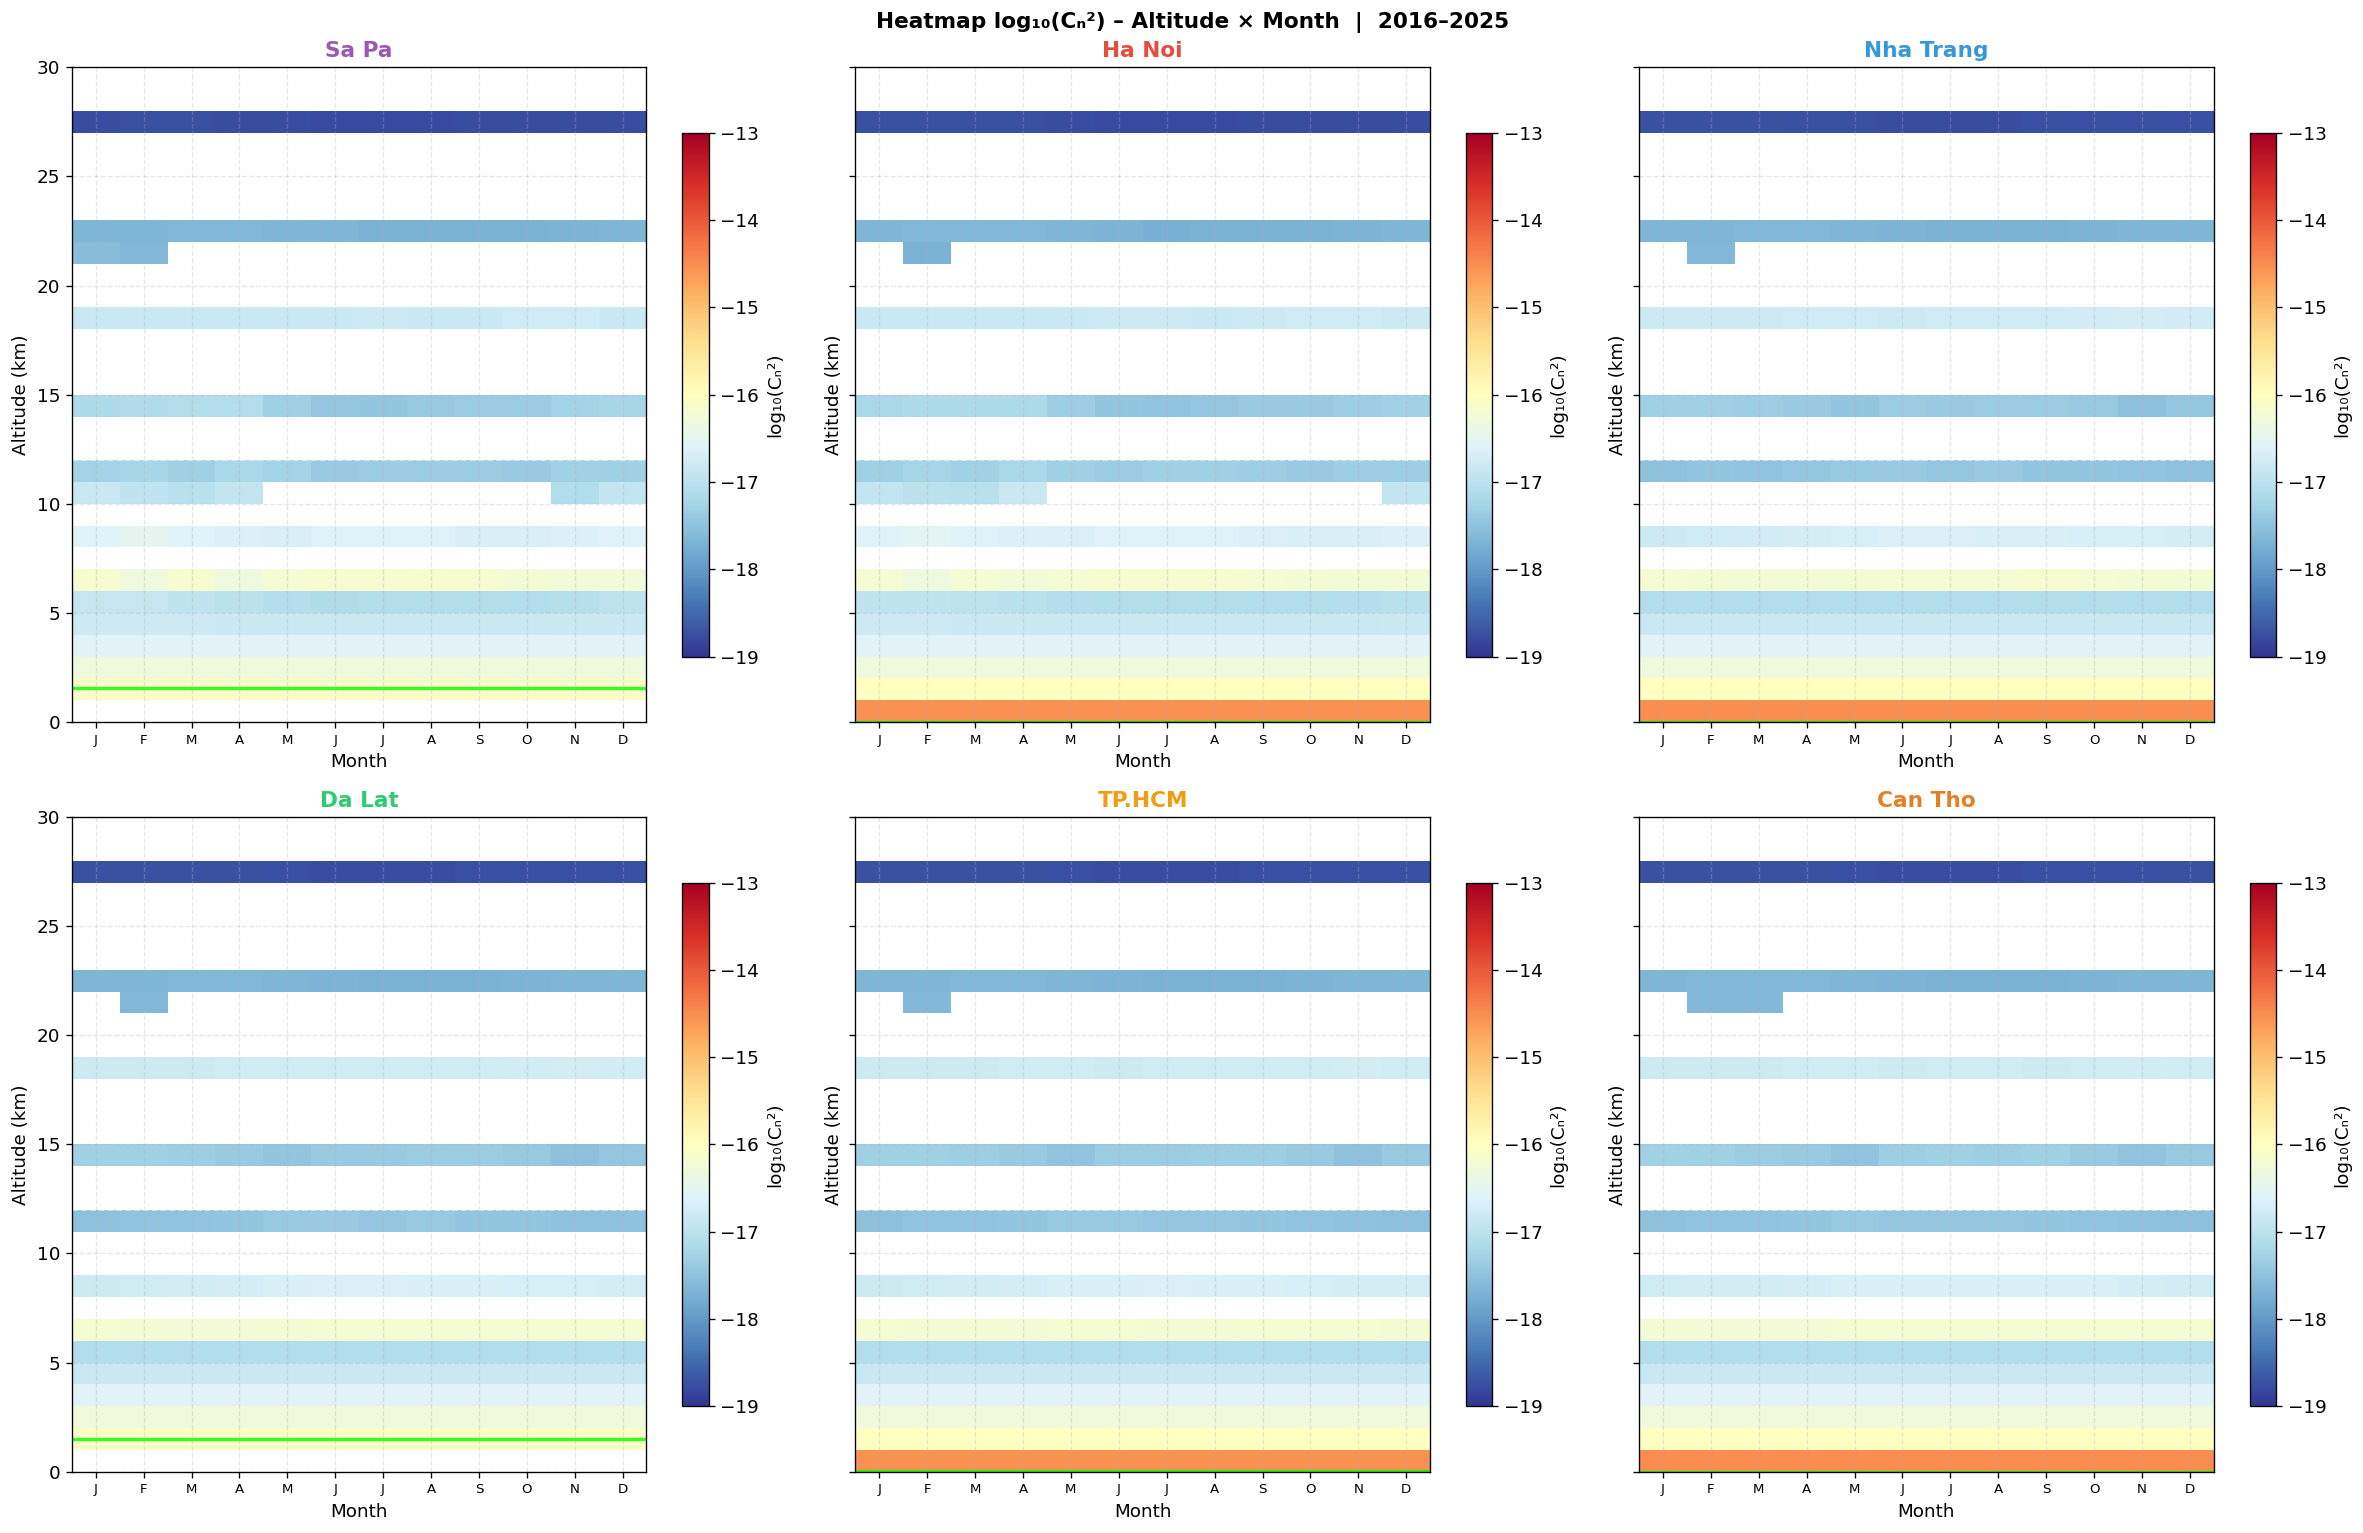

Saved fig05


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13), sharey=True)
fig.suptitle('Heatmap log\u2081\u2080(C\u2099\u00b2) – Altitude × Month  |  2016–2025',
             fontsize=13, fontweight='bold')

mlabs12 = ['J','F','M','A','M','J','J','A','S','O','N','D']
h_bins  = np.linspace(0, 30000, 31)      # 1 km bins
h_ctrs  = 0.5 * (h_bins[:-1] + h_bins[1:])

for ax, city in zip(axes.flatten(), CITY_KEYS):
    cfg     = CITIES[city]
    cn2_arr = full[city]['cn2']
    h_arr   = full[city]['h']
    tm      = full[city]['time']
    hmap    = np.full((12, len(h_ctrs)), np.nan)

    for mi, m in enumerate(range(1, 13)):
        mask = tm.month == m
        if mask.sum() == 0: continue
        c_m = cn2_arr[mask]; h_m = h_arr[mask]
        for bi in range(len(h_ctrs)):
            inb  = (h_m >= h_bins[bi]) & (h_m < h_bins[bi+1])
            vals = c_m[inb]
            if vals.size:
                hmap[mi, bi] = np.log10(np.nanmean(np.clip(vals, 1e-20, None)))

    im = ax.pcolormesh(np.arange(1,13), h_ctrs/1000, hmap.T,
                       cmap='RdYlBu_r', vmin=-19, vmax=-13, shading='auto')
    plt.colorbar(im, ax=ax, label='log\u2081\u2080(C\u2099\u00b2)', shrink=0.8)
    ax.set_xticks(range(1,13)); ax.set_xticklabels(mlabs12, fontsize=8)
    ax.set_xlabel('Month'); ax.set_ylabel('Altitude (km)')
    ax.set_title(city, fontweight='bold', color=cfg['color'])
    ax.axhline(12, color='white', ls='--', alpha=0.6, lw=1)
    ax.axhline(cfg['elev']/1000, color='lime', ls='-', lw=2, alpha=0.8)
    ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig05_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig05')

## 10. Boxplot & Violin – So Sánh 6 Thành Phố

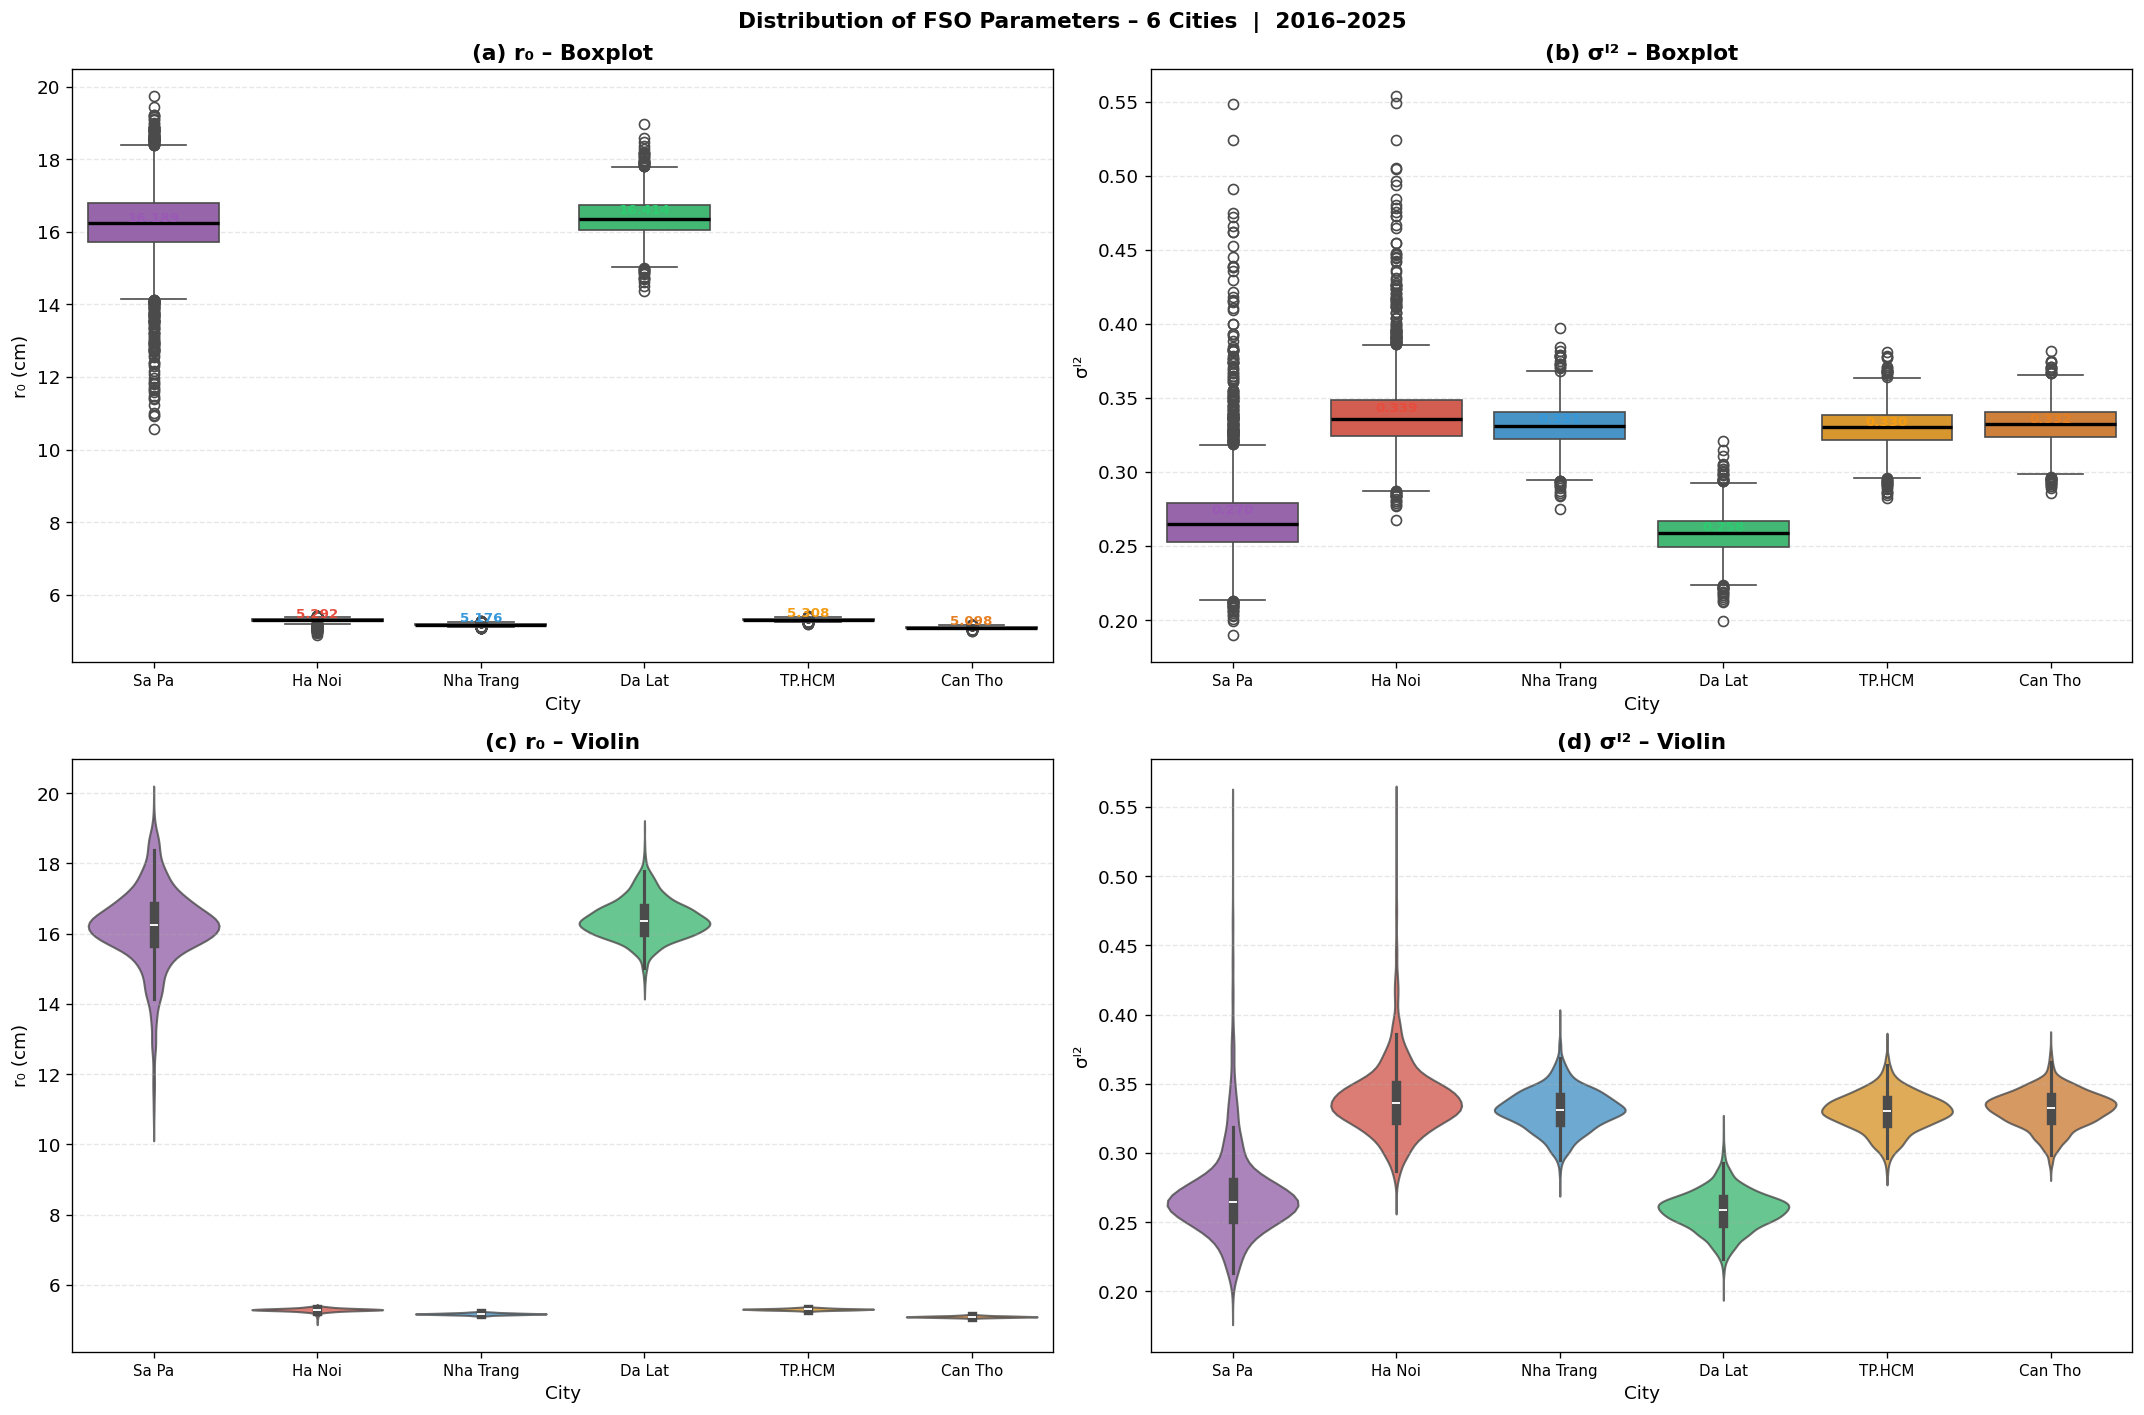

Saved fig06


In [11]:
all_dfs = []
for city in CITY_KEYS:
    d = fso[city].copy(); d['city'] = city
    all_dfs.append(d.reset_index())
df_all = pd.concat(all_dfs, ignore_index=True)

palette = {c: CITIES[c]['color'] for c in CITY_KEYS}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Distribution of FSO Parameters – 6 Cities  |  2016–2025',
             fontsize=13, fontweight='bold')

for ax, (col, ylabel, kind, title) in zip(axes.flatten(), [
    ('r0_cm',   'r\u2080 (cm)',  'box',    '(a) r\u2080 – Boxplot'),
    ('sigma2_I','\u03c3\u1d35\u00b2','box','(b) \u03c3\u1d35\u00b2 – Boxplot'),
    ('r0_cm',   'r\u2080 (cm)',  'violin', '(c) r\u2080 – Violin'),
    ('sigma2_I','\u03c3\u1d35\u00b2','violin','(d) \u03c3\u1d35\u00b2 – Violin'),
]):
    if kind == 'box':
        sns.boxplot(data=df_all, x='city', y=col, palette=palette,
                    order=CITY_KEYS, ax=ax,
                    medianprops=dict(color='black', lw=2))
        for i, city in enumerate(CITY_KEYS):
            mv = df_all.loc[df_all['city']==city, col].mean()
            ax.text(i, mv, f'{mv:.3f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color=CITIES[city]['color'])
    else:
        sns.violinplot(data=df_all, x='city', y=col, palette=palette,
                       order=CITY_KEYS, ax=ax, inner='box', alpha=0.8)
    ax.set_xlabel('City'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig06_boxplot_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig06')

## 11. CDF – Xác Suất Tích Lũy

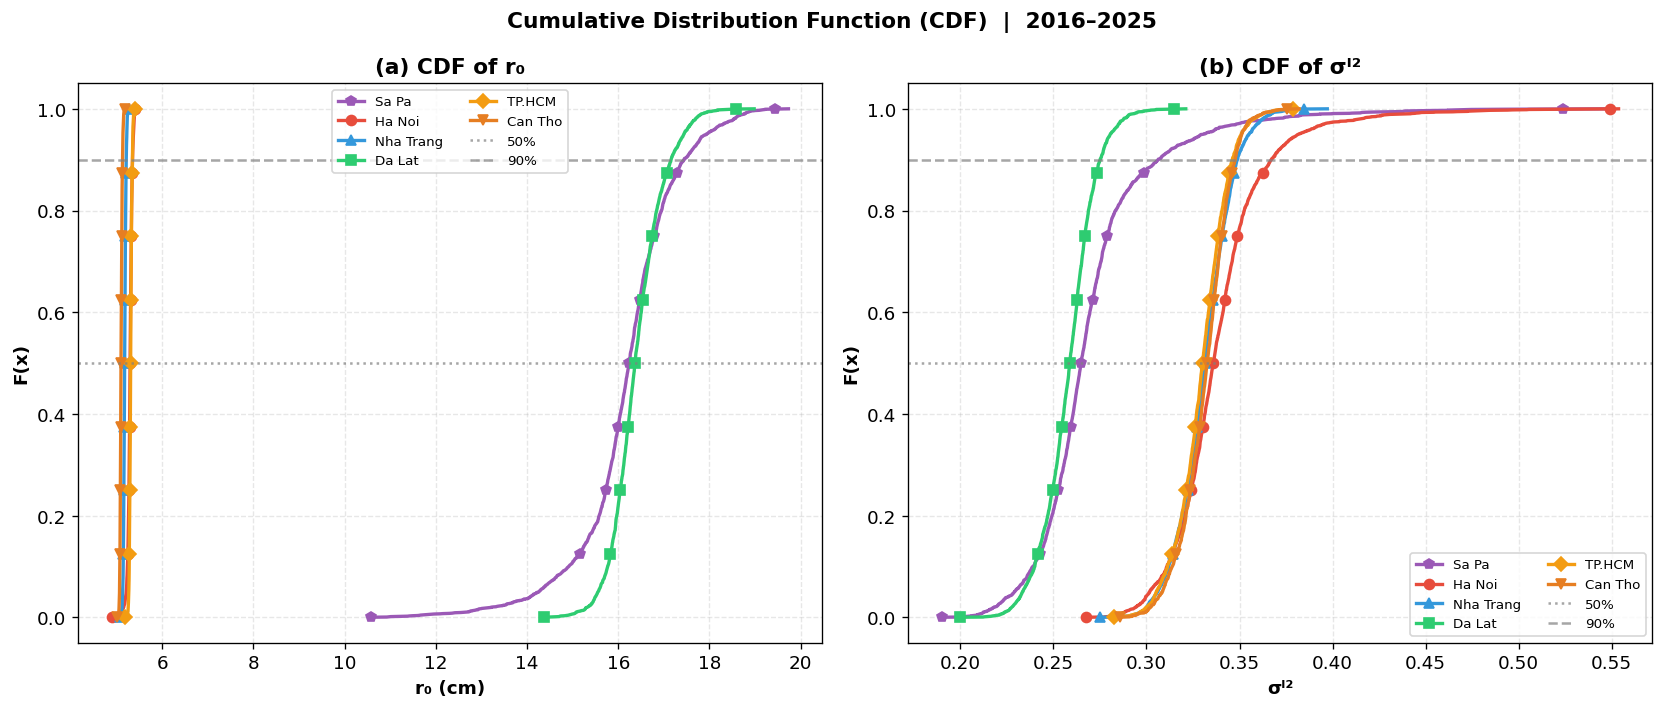

Saved fig07


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cumulative Distribution Function (CDF)  |  2016–2025',
             fontsize=13, fontweight='bold')

for city in CITY_KEYS:
    cfg = CITIES[city]
    df  = fso[city]
    for ax, col, xlabel in zip(axes,
        ['r0_cm', 'sigma2_I'],
        ['r\u2080 (cm)', '\u03c3\u1d35\u00b2']):
        sv  = np.sort(df[col].dropna())
        cdf = np.arange(1, len(sv)+1) / len(sv)
        ax.plot(sv, cdf, color=cfg['color'], lw=2,
                marker=cfg['marker'], markevery=len(sv)//8, ms=6, label=city)

for ax, (xlabel, ttl) in zip(axes, [
    ('r\u2080 (cm)',   '(a) CDF of r\u2080'),
    ('\u03c3\u1d35\u00b2','(b) CDF of \u03c3\u1d35\u00b2'),
]):
    ax.axhline(0.5, color='gray', ls=':', alpha=0.7, label='50%')
    ax.axhline(0.9, color='gray', ls='--',alpha=0.7, label='90%')
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel('F(x)', fontweight='bold')
    ax.set_title(ttl, fontweight='bold')
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig07_cdf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig07')

## 12. Annual Trend 2016–2025

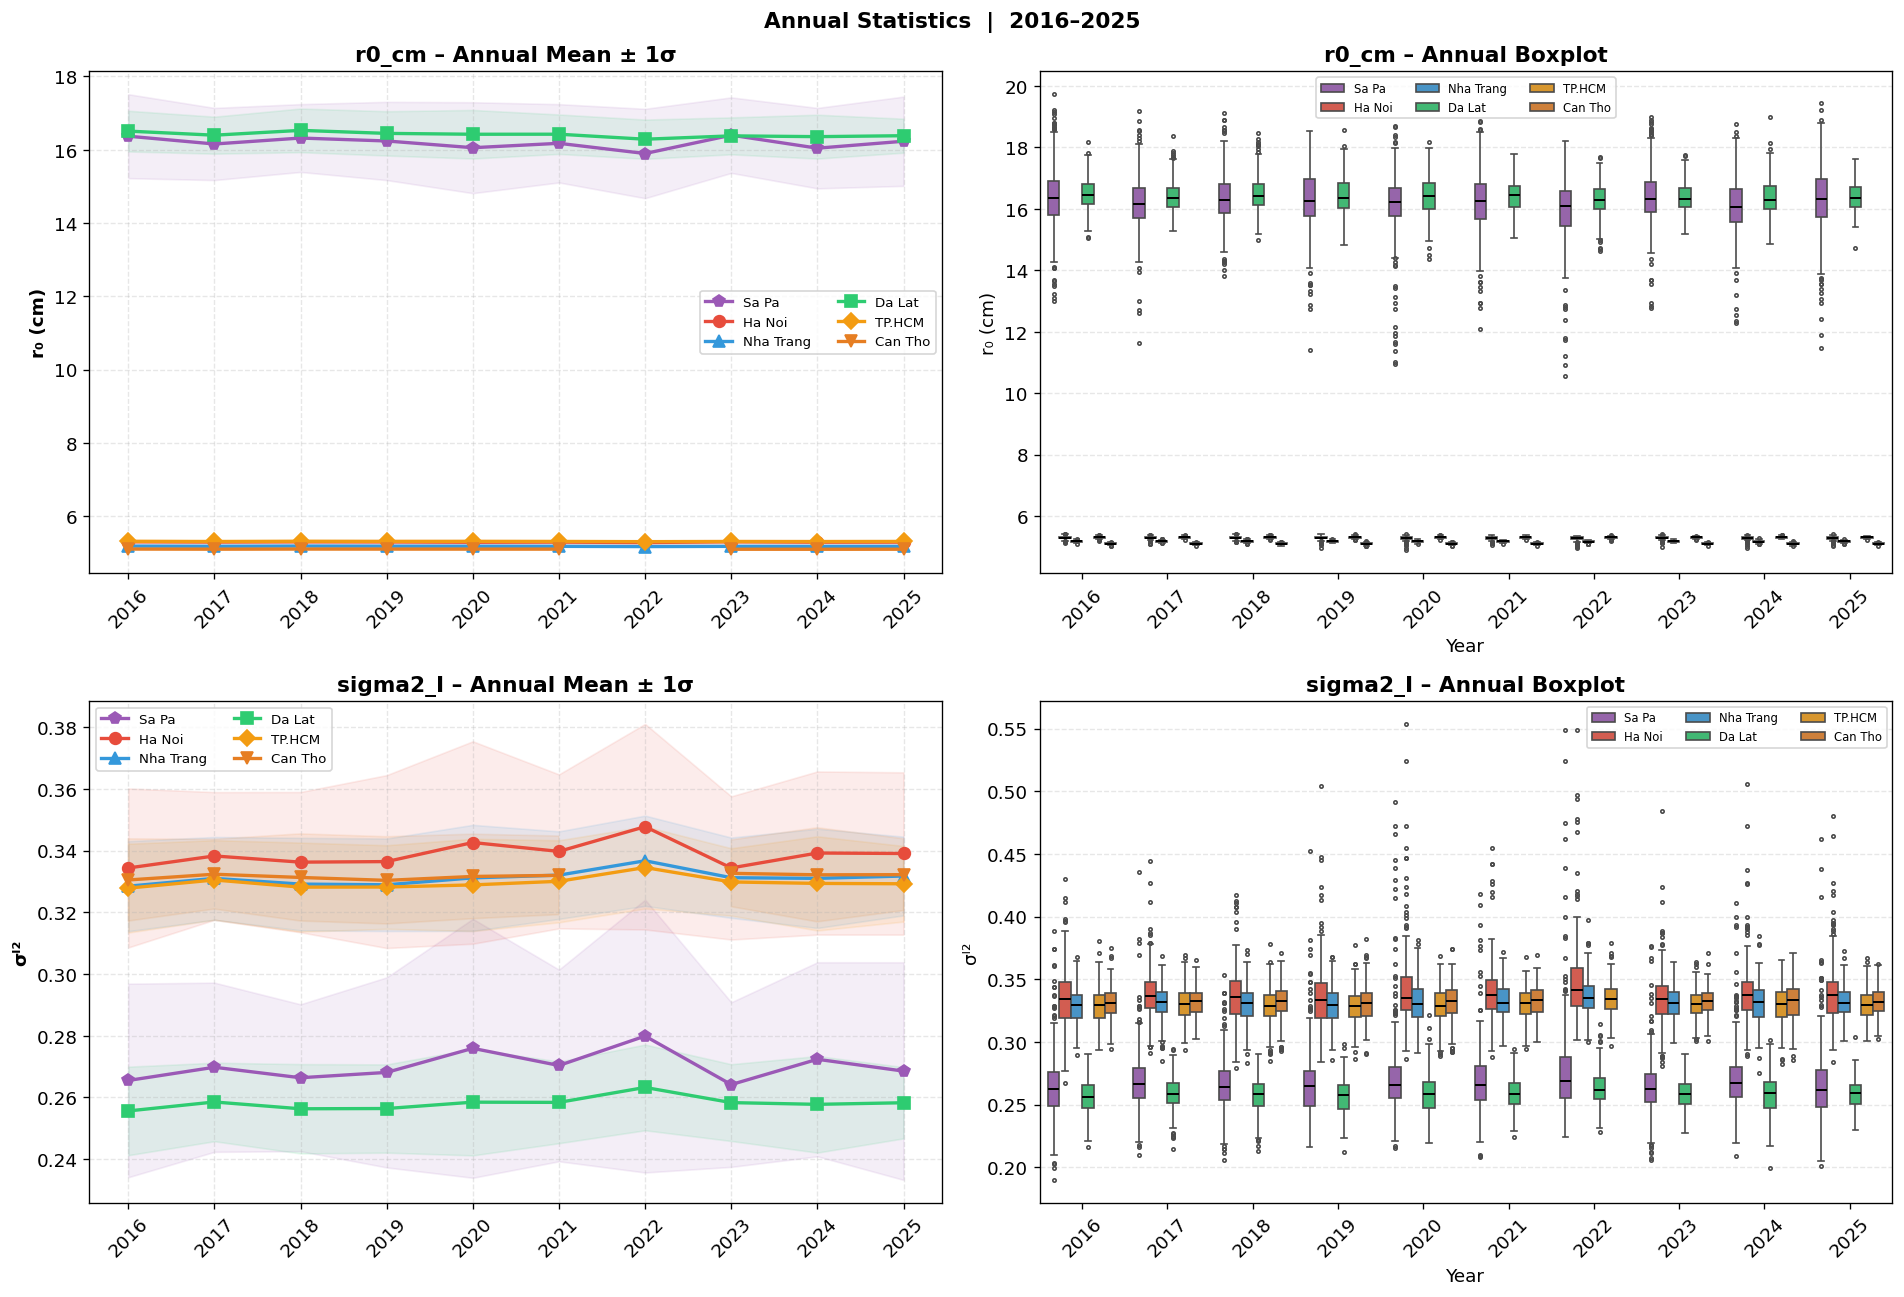

Saved fig08


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Annual Statistics  |  2016–2025',
             fontsize=13, fontweight='bold')

yr_labels = [str(y) for y in YEARS]

for ax_row, (col, ylabel) in enumerate([
    ('r0_cm',   'r\u2080 (cm)'),
    ('sigma2_I','\u03c3\u1d35\u00b2'),
]):
    # Left: line chart of annual means
    ax1 = axes[ax_row, 0]
    for city in CITY_KEYS:
        cfg   = CITIES[city]
        means = [fso[city].loc[fso[city]['year']==y, col].mean() for y in YEARS]
        stds  = [fso[city].loc[fso[city]['year']==y, col].std()  for y in YEARS]
        ax1.plot(yr_labels, means, 'o-', color=cfg['color'],
                 marker=cfg['marker'], label=city, lw=2, ms=7)
        ax1.fill_between(yr_labels,
                         np.array(means)-np.array(stds),
                         np.array(means)+np.array(stds),
                         alpha=0.10, color=cfg['color'])
    ax1.set_ylabel(ylabel, fontweight='bold')
    ax1.set_title(f'{col} – Annual Mean ± 1σ', fontweight='bold')
    ax1.legend(fontsize=8, ncol=2)
    ax1.tick_params(axis='x', rotation=45)

    # Right: boxplot by year, all cities
    ax2 = axes[ax_row, 1]
    df_yr = df_all[['city','year',col]].copy()
    df_yr['yr_str'] = df_yr['year'].astype(str)
    sns.boxplot(data=df_yr, x='yr_str', y=col, hue='city',
                palette={c: CITIES[c]['color'] for c in CITY_KEYS},
                order=yr_labels, ax=ax2,
                medianprops=dict(color='black', lw=1.2),
                flierprops=dict(markersize=2))
    ax2.set_xlabel('Year'); ax2.set_ylabel(ylabel)
    ax2.set_title(f'{col} – Annual Boxplot', fontweight='bold')
    ax2.legend(fontsize=7, ncol=3)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig08_annual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig08')

## 13. Tương Quan & Scatter r₀ vs σI²

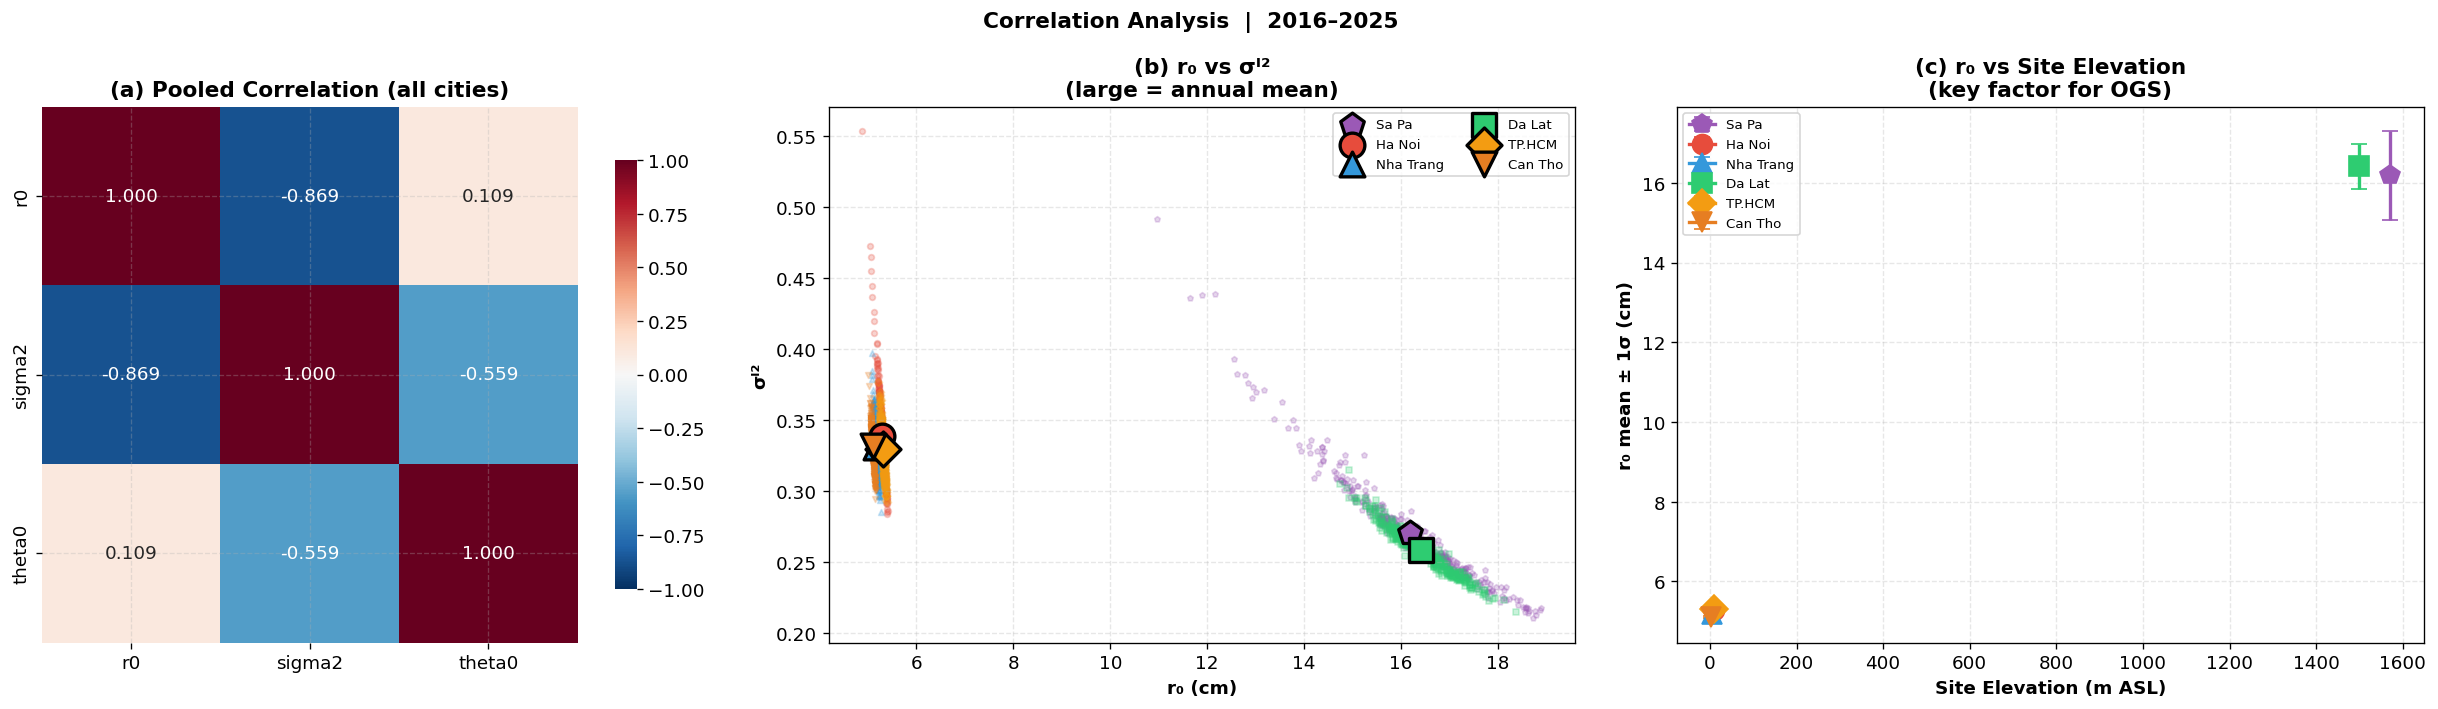

Saved fig09


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Correlation Analysis  |  2016–2025', fontsize=13, fontweight='bold')

# (a) Correlation heatmap – all-city pooled
ax = axes[0]
corr_cols = {'r0_cm':'r0','sigma2_I':'sigma2','theta0_as':'theta0'}
df_corr = df_all[list(corr_cols.keys())].rename(columns=corr_cols).corr()
sns.heatmap(df_corr, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('(a) Pooled Correlation (all cities)', fontweight='bold')

# (b) r0 vs sigma2 scatter
ax = axes[1]
for city in CITY_KEYS:
    cfg  = CITIES[city]
    df_s = fso[city].sample(min(500, len(fso[city])), random_state=42)
    ax.scatter(df_s['r0_cm'], df_s['sigma2_I'],
               color=cfg['color'], alpha=0.25, s=12, marker=cfg['marker'])
    ax.scatter(fso[city]['r0_cm'].mean(), fso[city]['sigma2_I'].mean(),
               color=cfg['color'], s=220, marker=cfg['marker'],
               edgecolors='black', lw=2, zorder=10, label=city)
ax.set_xlabel('r\u2080 (cm)', fontweight='bold')
ax.set_ylabel('\u03c3\u1d35\u00b2', fontweight='bold')
ax.set_title('(b) r\u2080 vs \u03c3\u1d35\u00b2\n(large = annual mean)', fontweight='bold')
ax.legend(fontsize=8, ncol=2)

# (c) Elevation vs r0 scatter
ax = axes[2]
for city in CITY_KEYS:
    cfg = CITIES[city]
    r0m = fso[city]['r0_cm'].mean()
    r0s = fso[city]['r0_cm'].std()
    ax.errorbar(cfg['elev'], r0m, yerr=r0s,
                color=cfg['color'], marker=cfg['marker'], ms=12,
                lw=2, capsize=5, label=city)
ax.set_xlabel('Site Elevation (m ASL)', fontweight='bold')
ax.set_ylabel('r\u2080 mean \u00b1 1\u03c3 (cm)', fontweight='bold')
ax.set_title('(c) r\u2080 vs Site Elevation\n(key factor for OGS)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig09_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig09')

## 14. Summary Statistics & Data-Driven OGS Ranking

In [15]:
# ── Summary statistics ────────────────────────────────────
stats = {}
for city in CITY_KEYS:
    df = fso[city]
    C0 = C0_ref * np.exp(-CITIES[city]['elev'] / H_SCALE)
    stats[city] = {
        'Elev(m)':    CITIES[city]['elev'],
        'Lat':        CITIES[city]['lat'],
        'C0':         C0,
        'r0_mean':    df['r0_cm'].mean(),
        'r0_std':     df['r0_cm'].std(),
        'r0_p10':     df['r0_cm'].quantile(0.10),
        'r0_p50':     df['r0_cm'].quantile(0.50),
        'r0_p90':     df['r0_cm'].quantile(0.90),
        'si_mean':    df['sigma2_I'].mean(),
        'si_std':     df['sigma2_I'].std(),
        'si_p50':     df['sigma2_I'].quantile(0.50),
        'th0_mean':   df['theta0_as'].mean(),
    }

df_stats = pd.DataFrame(stats).T
df_stats.index.name = 'City'
print('='*80)
print('TABLE 1: FULL SUMMARY STATISTICS  (ERA5 + HV PBL, 2016–2025)')
print('='*80)
print(df_stats.round(5).to_string())

# ── OGS Ranking ───────────────────────────────────────────
def norm_high(x): return (x-x.min())/(x.max()-x.min()+1e-20)
def norm_low(x):  return 1.0 - norm_high(x)

r0v  = np.array([stats[c]['r0_mean']  for c in CITY_KEYS])
siv  = np.array([stats[c]['si_mean']  for c in CITY_KEYS])
thv  = np.array([stats[c]['th0_mean'] for c in CITY_KEYS])
elev = np.array([stats[c]['Elev(m)']  for c in CITY_KEYS])

# Composite: equal weight r0↑, sigma↓, theta0↑
scores = (norm_high(r0v) + norm_low(siv) + norm_high(thv)) / 3.0 * 100.0

df_rank = pd.DataFrame({
    'City':      CITY_KEYS,
    'Elev(m)':   elev.astype(int),
    'r0(cm)':    np.round(r0v, 4),
    'sigma2':    np.round(siv, 6),
    'theta0(as)':np.round(thv, 4),
    'Score(%)':  np.round(scores, 2),
})
df_rank = df_rank.sort_values('Score(%)', ascending=False).reset_index(drop=True)
df_rank.index += 1

print('\n' + '='*70)
print('TABLE 2: OGS SITE RANKING  (Data-Driven, Equal Weights)')
print('Criterion: r0 ↑ (high = good) | sigma2 ↓ | theta0 ↑')
print('='*70)
print(df_rank.to_string())

medals = ['1st (Gold)', '2nd (Silver)', '3rd (Bronze)', '4th', '5th', '6th']
print()
for i, row in df_rank.iterrows():
    print(f'  {medals[i-1]}: {row["City"]:<12} | Score={row["Score(%)"]:.1f}% | '
          f'r0={row["r0(cm)"]:.4f}cm | sigma2={row["sigma2"]:.6f} | '
          f'elev={row["Elev(m)"]}m')

best = df_rank.iloc[0]
print(f'\n>>> RECOMMENDED OGS: {best["City"]} (Score: {best["Score(%)"]:.1f}%)')

# Save
df_stats.to_csv(SAVE_DIR / 'table1_summary_stats.csv', encoding='utf-8-sig')
df_rank.to_csv(SAVE_DIR / 'table2_ogs_ranking.csv', encoding='utf-8-sig')
print('CSVs saved.')

TABLE 1: FULL SUMMARY STATISTICS  (ERA5 + HV PBL, 2016–2025)
           Elev(m)    Lat   C0   r0_mean   r0_std    r0_p10    r0_p50    r0_p90  si_mean   si_std   si_p50  th0_mean
City                                                                                                                
Sa Pa       1570.0  22.34  0.0  16.18911  1.11293  14.91474  16.24157  17.43932  0.27010  0.03323  0.26486   1.05452
Ha Noi        10.0  21.02  0.0   5.29159  0.05217   5.23744   5.29516   5.34852  0.33881  0.02693  0.33593   1.04970
Nha Trang      5.0  12.24  0.0   5.17602  0.02706   5.14324   5.17556   5.21097  0.33114  0.01478  0.33127   1.06276
Da Lat      1500.0  11.94  0.0  16.41399  0.56256  15.76834  16.36466  17.15784  0.25814  0.01419  0.25872   1.07238
TP.HCM        10.0  10.82  0.0   5.30809  0.02665   5.27632   5.30747   5.34319  0.32966  0.01368  0.33015   1.06248
Can Tho        2.0  10.03  0.0   5.09769  0.02294   5.07056   5.09608   5.12784  0.33167  0.01314  0.33252   1.06429

TA

## 15. OGS Recommendation Figure

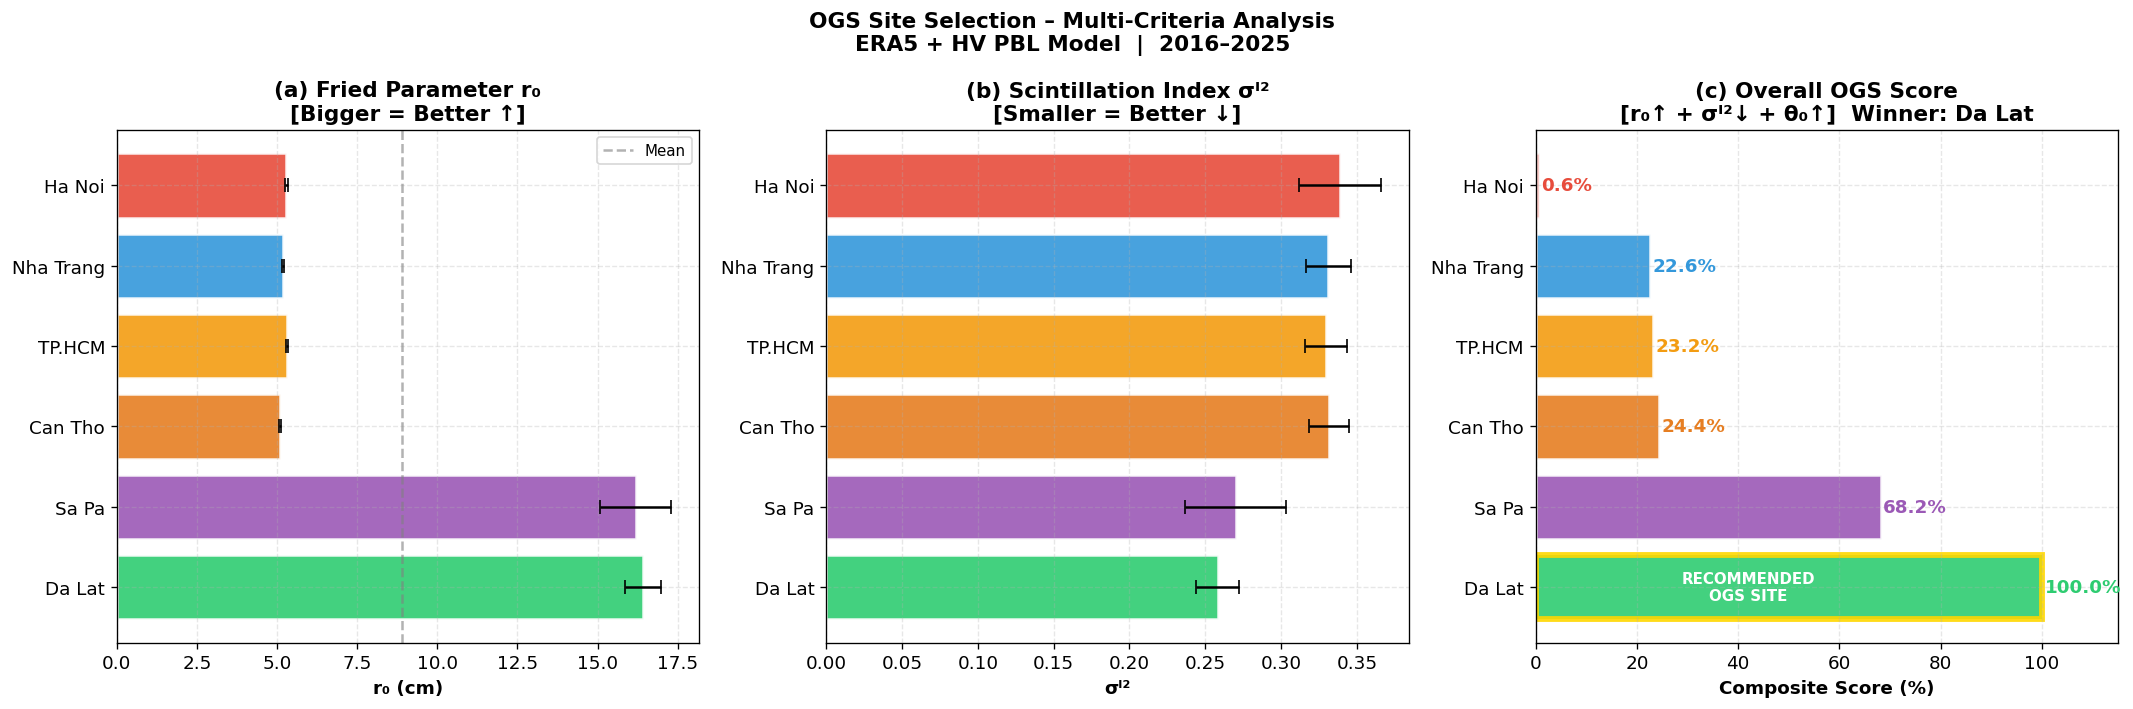

Saved fig10


In [16]:
cities_s  = list(df_rank['City'])
scores_s  = list(df_rank['Score(%)'])
r0_s      = [stats[c]['r0_mean'] for c in cities_s]
si_s      = [stats[c]['si_mean'] for c in cities_s]
elev_s    = [stats[c]['Elev(m)'] for c in cities_s]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('OGS Site Selection – Multi-Criteria Analysis\n'
             'ERA5 + HV PBL Model  |  2016–2025',
             fontsize=13, fontweight='bold')

# (a) r0
ax = axes[0]
bars_a = ax.barh(cities_s, [stats[c]['r0_mean'] for c in cities_s],
                 xerr=[stats[c]['r0_std'] for c in cities_s],
                 color=[CITIES[c]['color'] for c in cities_s],
                 edgecolor='white', lw=1.5, alpha=0.9,
                 error_kw=dict(elinewidth=1.5, capsize=4))
ax.set_xlabel('r\u2080 (cm)', fontweight='bold')
ax.set_title('(a) Fried Parameter r\u2080\n[Bigger = Better ↑]', fontweight='bold')
ax.axvline(np.mean(r0v), color='gray', ls='--', alpha=0.6, label='Mean')
ax.legend(fontsize=9)

# (b) sigma2
ax = axes[1]
ax.barh(cities_s, [stats[c]['si_mean'] for c in cities_s],
        xerr=[stats[c]['si_std'] for c in cities_s],
        color=[CITIES[c]['color'] for c in cities_s],
        edgecolor='white', lw=1.5, alpha=0.9,
        error_kw=dict(elinewidth=1.5, capsize=4))
ax.set_xlabel('\u03c3\u1d35\u00b2', fontweight='bold')
ax.set_title('(b) Scintillation Index \u03c3\u1d35\u00b2\n[Smaller = Better ↓]', fontweight='bold')

# (c) Composite score
ax = axes[2]
bars = ax.barh(cities_s, scores_s,
               color=[CITIES[c]['color'] for c in cities_s],
               edgecolor='white', lw=1.5, alpha=0.9)
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3.5)

for bar, val, city in zip(bars, scores_s, cities_s):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11,
            fontweight='bold', color=CITIES[city]['color'])

ax.text(scores_s[0]*0.42, bars[0].get_y() + bars[0].get_height()/2,
        'RECOMMENDED\nOGS SITE', va='center', ha='center',
        fontsize=9, fontweight='bold', color='white')

ax.set_xlabel('Composite Score (%)', fontweight='bold')
ax.set_title(f'(c) Overall OGS Score\n[r\u2080\u2191 + \u03c3\u1d35\u00b2\u2193 + \u03b8\u2080\u2191]  Winner: {cities_s[0]}',
             fontweight='bold')
ax.set_xlim(0, 115)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig10_ogs_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig10')

## 16. Master Dashboard

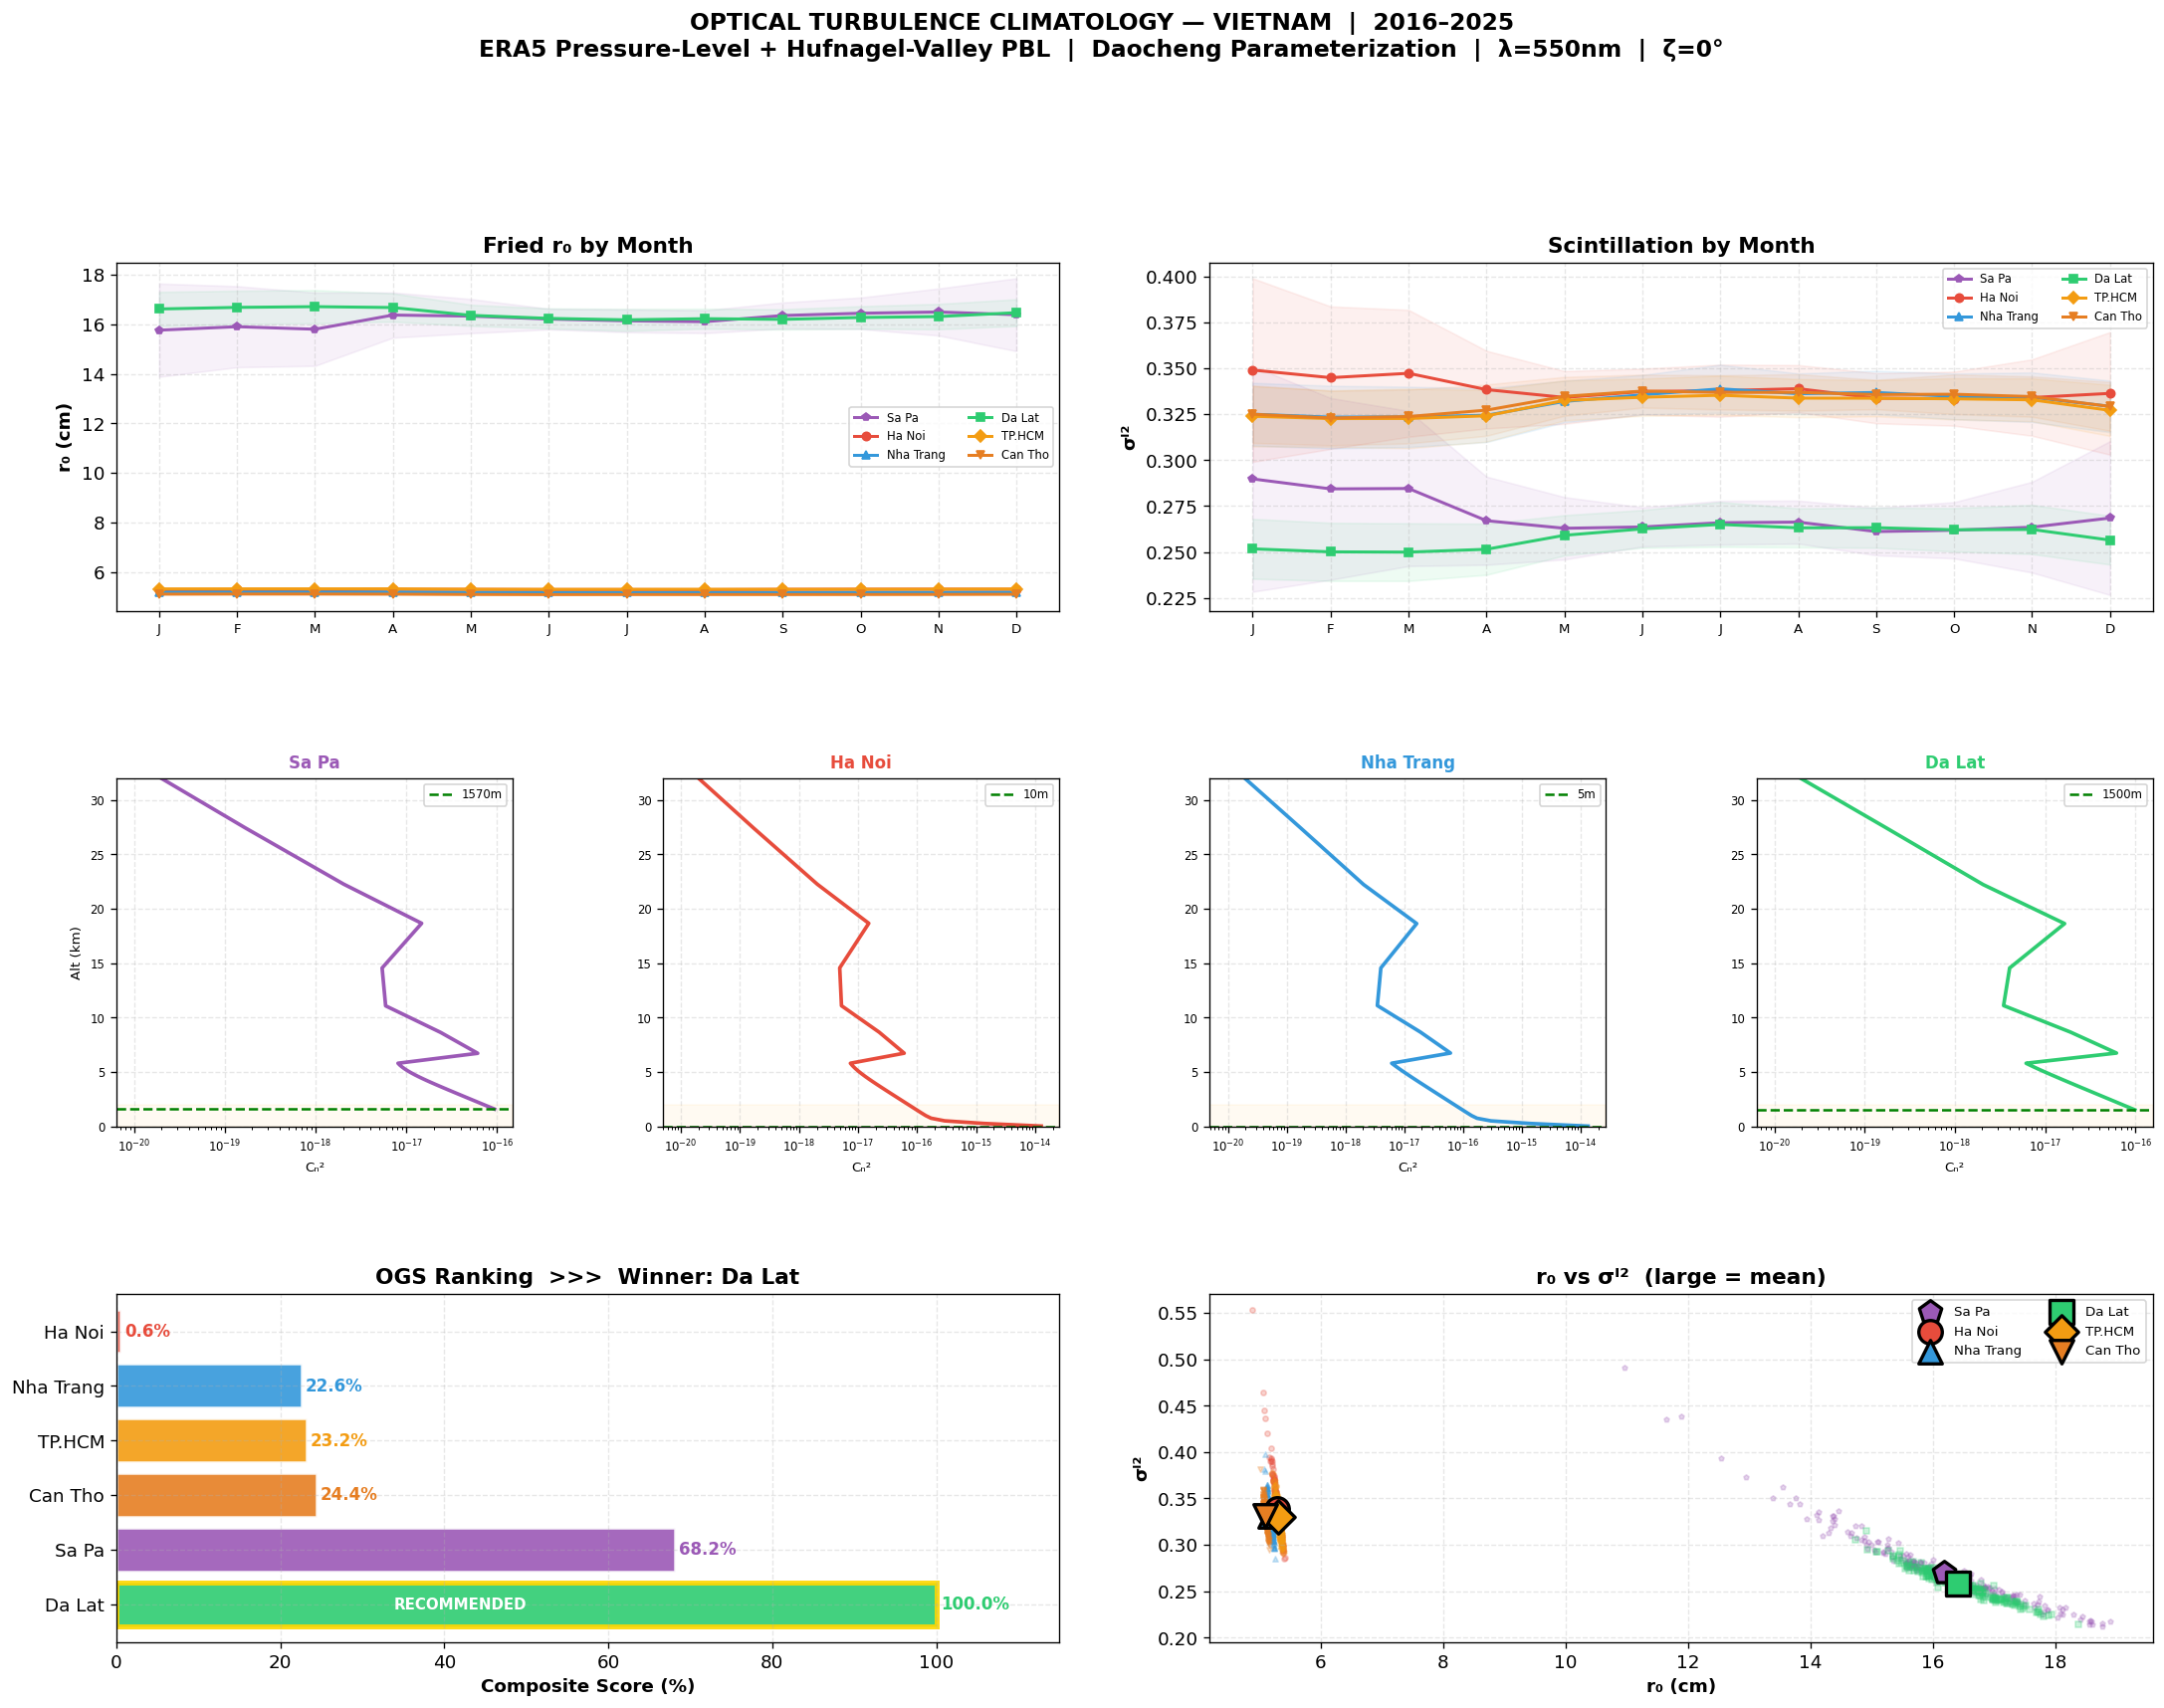

Saved fig00 (master dashboard)


In [17]:
fig = plt.figure(figsize=(22, 15))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.38)
fig.suptitle(
    'OPTICAL TURBULENCE CLIMATOLOGY — VIETNAM  |  2016–2025\n'
    'ERA5 Pressure-Level + Hufnagel-Valley PBL  |  Daocheng Parameterization  |  \u03bb=550nm  |  \u03b6=0\u00b0',
    fontsize=14, fontweight='bold', y=1.02
)

mlabs = ['J','F','M','A','M','J','J','A','S','O','N','D']

# Row 0: monthly r0 and sigma2
for ci, (col, ylabel, title) in enumerate([
    ('r0_cm',   'r\u2080 (cm)', 'Fried r\u2080 by Month'),
    ('sigma2_I','\u03c3\u1d35\u00b2', 'Scintillation by Month'),
]):
    ax = fig.add_subplot(gs[0, ci*2:(ci+1)*2])
    for city in CITY_KEYS:
        cfg = CITIES[city]
        m   = fso[city][col].groupby(fso[city]['month']).mean()
        s   = fso[city][col].groupby(fso[city]['month']).std()
        ax.plot(m.index, m.values, 'o-', color=cfg['color'],
                marker=cfg['marker'], label=city, lw=1.8, ms=5)
        ax.fill_between(m.index, m-s, m+s, alpha=0.08, color=cfg['color'])
    ax.set_xticks(range(1,13)); ax.set_xticklabels(mlabs, fontsize=8)
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, ncol=2)

# Row 1: Vertical profiles (annual mean) for each city
for ci, city in enumerate(CITY_KEYS):
    ax  = fig.add_subplot(gs[1, ci % 4]) if ci < 4 else None
    if ax is None: break   # only 4 panels in row
    cfg = CITIES[city]
    c2m = np.nanmean(full[city]['cn2'], axis=0)
    h2m = np.nanmean(full[city]['h'],   axis=0)
    idx = np.argsort(h2m)
    ax.semilogx(c2m[idx], h2m[idx]/1000, color=cfg['color'], lw=2.2)
    ax.axhline(cfg['elev']/1000, color='green', ls='--', lw=1.5,
               label=f'{cfg["elev"]}m')
    ax.axhspan(0, 2, alpha=0.05, color='orange')
    ax.set_xlabel('C\u2099\u00b2', fontsize=8)
    ax.set_ylabel('Alt (km)' if ci==0 else '', fontsize=8)
    ax.set_title(city, fontweight='bold', color=cfg['color'], fontsize=10)
    ax.set_ylim(0, 32); ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

# Row 2 left (2 cols): OGS ranking
ax = fig.add_subplot(gs[2, :2])
bars = ax.barh(cities_s, scores_s,
               color=[CITIES[c]['color'] for c in cities_s],
               edgecolor='white', lw=1.5, alpha=0.9)
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
for bar, val, city in zip(bars, scores_s, cities_s):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10,
            fontweight='bold', color=CITIES[city]['color'])
ax.text(scores_s[0]*0.42, bars[0].get_y()+bars[0].get_height()/2,
        'RECOMMENDED', va='center', ha='center',
        fontsize=9, fontweight='bold', color='white')
ax.set_xlabel('Composite Score (%)', fontweight='bold')
ax.set_title(f'OGS Ranking  >>>  Winner: {cities_s[0]}', fontweight='bold')
ax.set_xlim(0, 115)

# Row 2 right (2 cols): r0 vs sigma2 scatter
ax = fig.add_subplot(gs[2, 2:])
for city in CITY_KEYS:
    cfg = CITIES[city]
    ds_ = fso[city].sample(min(300, len(fso[city])), random_state=42)
    ax.scatter(ds_['r0_cm'], ds_['sigma2_I'],
               color=cfg['color'], alpha=0.25, s=10, marker=cfg['marker'])
    ax.scatter(fso[city]['r0_cm'].mean(), fso[city]['sigma2_I'].mean(),
               color=cfg['color'], s=200, marker=cfg['marker'],
               edgecolors='black', lw=2, zorder=10, label=city)
ax.set_xlabel('r\u2080 (cm)', fontweight='bold')
ax.set_ylabel('\u03c3\u1d35\u00b2', fontweight='bold')
ax.set_title('r\u2080 vs \u03c3\u1d35\u00b2  (large = mean)', fontweight='bold')
ax.legend(fontsize=8, ncol=2)

plt.savefig(SAVE_DIR / 'fig00_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig00 (master dashboard)')

## 17. Kết Luận – Data-Driven

In [18]:
SEP = '=' * 72
print(SEP)
print('OPTICAL TURBULENCE CLIMATOLOGY — VIETNAM  (ERA5 + HV PBL, 2016–2025)')
print('Daocheng Parameterization  |  lambda=550nm  |  zenith=0 deg')
print(SEP)

print('\n[DATA & METHOD]')
print(f'  ERA5 pressure levels: 500-1 hPa => covers ~5.8-48 km ASL')
print(f'  PBL (0-5.8 km): Hufnagel-Valley with elevation correction')
print(f'  C0_ref = {C0_ref:.2e}, H_scale = {H_SCALE:.0f} m')
print(f'  Total days per city: {len(fso[CITY_KEYS[0]])}')

print('\n[RQ1] SPATIAL DISTRIBUTION OF Cn2:')
print(f'  {"City":<12} {"Elev(m)":>8} {"C0":>10} {"log10(Cn2)":>12} {"r0(cm)":>10} {"sigma2":>10}')
print('  ' + '-'*65)
for city in CITY_KEYS:
    C0   = C0_ref * np.exp(-CITIES[city]['elev'] / H_SCALE)
    lcn2 = np.log10(np.nanmean(full[city]['cn2']))
    r0m  = fso[city]['r0_cm'].mean()
    sim  = fso[city]['sigma2_I'].mean()
    print(f'  {city:<12} {CITIES[city]["elev"]:>8} {C0:>10.2e} {lcn2:>12.3f} {r0m:>10.4f} {sim:>10.6f}')

print('\n[RQ2] SEASONAL PATTERN:')
for city in CITY_KEYS:
    r0s  = fso[city].groupby('season')['r0_cm'].mean()
    best = r0s.idxmax(); worst = r0s.idxmin()
    print(f'  {city:<12}: Best r0 in {best} ({r0s[best]:.4f}cm) | '
          f'Worst in {worst} ({r0s[worst]:.4f}cm)')

print('\n[RQ3] OGS RANKING (composite: r0 high + sigma2 low + theta0 high):')
medals = ['Gold 1st', 'Silver 2nd', 'Bronze 3rd', '4th', '5th', '6th']
for i, row in df_rank.iterrows():
    print(f'  {medals[i-1]}: {row["City"]:<12} | Score={row["Score(%)"]:.1f}% | '
          f'r0={row["r0(cm)"]:.4f}cm | sigma2={row["sigma2"]:.6f} | '
          f'elev={row["Elev(m)"]}m')

best = df_rank.iloc[0]
print(f'\n>>> RECOMMENDED OGS SITE: {best["City"]} (Score: {best["Score(%)"]:.1f}%)')
print(f'    r0     = {best["r0(cm)"]:.4f} cm')
print(f'    sigma2 = {best["sigma2"]:.6f}')
print(f'    theta0 = {best["theta0(as)"]:.4f} arcsec')
print(f'    Elev   = {best["Elev(m)"]} m ASL')

print('\n[CAVEATS]')
print('  1. PBL modeled via HV formula; C0 depends on C0_ref & H_scale assumptions.')
print('  2. ERA5 daily temporal resolution; sub-daily turbulence not captured.')
print('  3. Cloud cover, logistics, safety not considered in this ranking.')
print('  4. For site confirmation: in-situ DIMM/SCIDAR measurements recommended.')
print(SEP)

OPTICAL TURBULENCE CLIMATOLOGY — VIETNAM  (ERA5 + HV PBL, 2016–2025)
Daocheng Parameterization  |  lambda=550nm  |  zenith=0 deg

[DATA & METHOD]
  ERA5 pressure levels: 500-1 hPa => covers ~5.8-48 km ASL
  PBL (0-5.8 km): Hufnagel-Valley with elevation correction
  C0_ref = 1.70e-14, H_scale = 1000 m
  Total days per city: 2370

[RQ1] SPATIAL DISTRIBUTION OF Cn2:
  City          Elev(m)         C0   log10(Cn2)     r0(cm)     sigma2
  -----------------------------------------------------------------
  Sa Pa            1570   3.54e-15      -16.563    16.1891   0.270105
  Ha Noi             10   1.68e-14      -15.339     5.2916   0.338807
  Nha Trang           5   1.69e-14      -15.318     5.1760   0.331140
  Da Lat           1500   3.79e-15      -16.559    16.4140   0.258140
  TP.HCM             10   1.68e-14      -15.339     5.3081   0.329656
  Can Tho             2   1.70e-14      -15.305     5.0977   0.331667

[RQ2] SEASONAL PATTERN:
  Sa Pa       : Best r0 in Thu (16.4345cm) | Worst

---
## References
1. Tatarskii (1961) *Wave Propagation in a Turbulent Medium*
2. Fried (1966) *JOSA* 56(10)
3. Hufnagel & Stanley (1964) *JOSA* 54
4. Valley (1980) *Applied Optics* 19(4)
5. Coulman & Vernin (1991) *Applied Optics* 30(1)
6. Hersbach et al. (2020) ERA5 reanalysis, *QJRMS*
7. Andrews & Phillips (2005) *Laser Beam Propagation through Random Media*, SPIE